## Environment Setup and GPU Verification

In this section, TensorFlow is initialized and GPU availability is checked.  
GPU acceleration is important for deep learning tasks because it significantly reduces training time when working with Convolutional Neural Networks (CNNs) and large image datasets.

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Google Drive Mounting

Google Drive is mounted to access the dataset and project files in Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Library Import and Environment Initialization

The required libraries for image processing, visualization, dataset handling, and deep learning are imported in this section. TensorFlow and Keras are used to build and train Convolutional Neural Network (CNN) models, while Scikit-learn is used for dataset splitting and evaluation metrics. The environment configuration and GPU availability are also verified before proceeding with model training.

In [ ]:
# STEP 1: Imports and environment check

import os
import zipfile
import shutil
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("Current folder:", os.getcwd())
print("Files in folder:", os.listdir())
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

Current folder: /content
Files in folder: ['.config', 'drive', 'sample_data']
TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Path Configuration

The dataset ZIP file is loaded from Google Drive. This file contains the original sports image dataset used for the image classification task.

In [ ]:
zip_path="/content/drive/MyDrive/ESPORTE/archive.zip"

# Dataset Preparation

## Dataset Extraction

The sports image dataset is extracted from the ZIP file stored in Google Drive. After extraction, the dataset structure is verified to ensure all folders and images are correctly loaded into the Colab environment.

In [ ]:
# ============================================================
# STEP 2: Extract Dataset from Google Drive
# ============================================================

import os
import zipfile

zip_path = "/content/drive/MyDrive/ESPORTE/archive.zip"
extract_path = "/content/data"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction done.")
else:
    print("Dataset already extracted.")

print("Extracted folder contents:")
print(os.listdir(extract_path))

Extraction done.
Extracted folder contents:
['data']


## Dataset Class Verification

The dataset folders are inspected to identify all available image classes. This helps verify the dataset structure and understand the categories available for image classification.

In [ ]:
# STEP 3: Check all available classes

data_path = "/content/data/data"

classes = os.listdir(data_path)

print("Total Classes:", len(classes))
print("Class Names:")
print(classes)

Total Classes: 22
Class Names:
['shooting', 'boxing', 'fencing', 'tennis', 'ice_hockey', 'motogp', 'formula1', 'chess', 'basketball', 'football', 'swimming', 'hockey', 'table_tennis', 'volleyball', 'cricket', 'baseball', 'kabaddi', 'wrestling', 'wwe', 'weight_lifting', 'badminton', 'gymnastics']


## Selection of Target Classes

The original dataset contains multiple sports categories. For this project, 12 representative sports classes were selected to create a balanced and computationally manageable image classification dataset.

In [ ]:
# STEP 4: Create selected 12-class dataset

selected_classes = [
    "badminton",
    "basketball",
    "football",
    "cricket",
    "table_tennis",
    "swimming",
    "shooting",
    "formula1",
    "boxing",
    "volleyball",
    "chess",
    "hockey"
]

source_path = "/content/data/data"
target_path = "/content/selected_dataset"

os.makedirs(target_path, exist_ok=True)

for class_name in selected_classes:
    src = os.path.join(source_path, class_name)
    dst = os.path.join(target_path, class_name)

    if not os.path.exists(src):
        print("Missing class folder:", src)
        continue

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

print("Selected dataset created.")
print("Total selected classes:", len(os.listdir(target_path)))
print("Selected classes:")

for cls in os.listdir(target_path):
    print("-", cls)

Selected dataset created.
Total selected classes: 12
Selected classes:
- shooting
- boxing
- formula1
- chess
- basketball
- football
- swimming
- hockey
- table_tennis
- volleyball
- cricket
- badminton


## Dataset Statistics and Image Distribution

The number of images in each selected sports category is calculated to understand the dataset distribution. This helps identify whether the dataset is balanced or imbalanced before model training.

In [ ]:
# STEP 5: Count images in selected 12-class dataset

target_path = "/content/selected_dataset"
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in selected_classes:
    class_path = os.path.join(target_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    class_counts[class_name] = len(images)

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print(df_counts)
print("\nTotal Images:", df_counts["Number of Images"].sum())
print("Number of Classes:", len(df_counts))

           Class  Number of Images
0      badminton               917
1     basketball               481
2       football               776
3        cricket               656
4   table_tennis               696
5       swimming               675
6       shooting               523
7       formula1               668
8         boxing               695
9     volleyball               690
10         chess               468
11        hockey               559

Total Images: 7804
Number of Classes: 12


## Visualization of Class Distribution

The class distribution is visualized using a bar chart to compare the number of images across all selected sports categories.

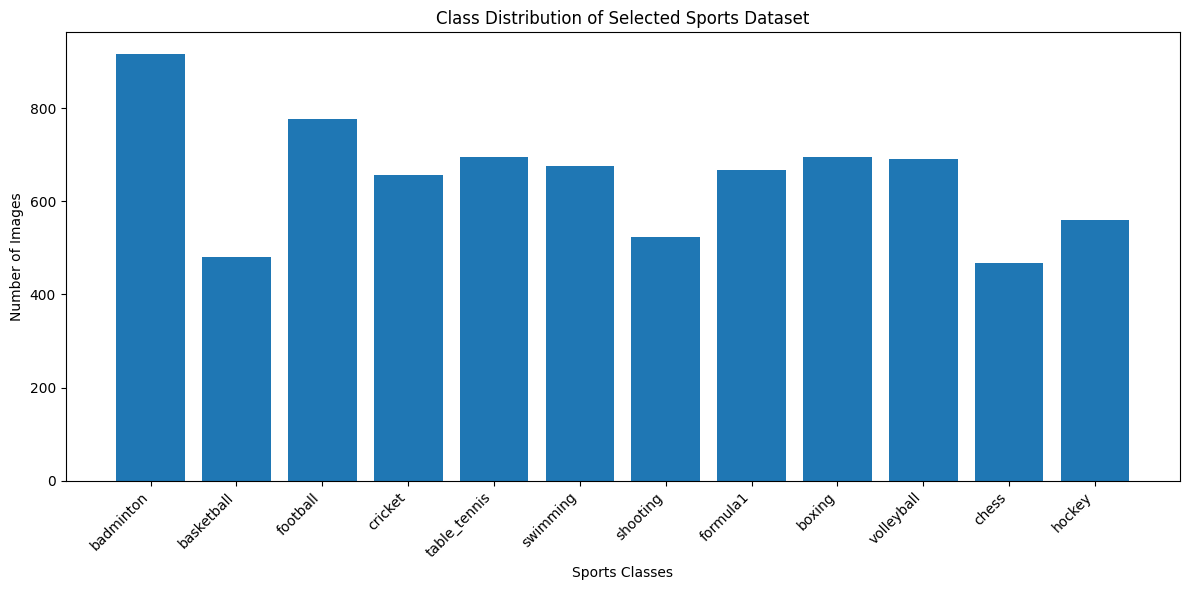

In [ ]:
# STEP 6: Visualize class distribution

plt.figure(figsize=(12, 6))
plt.bar(df_counts["Class"], df_counts["Number of Images"])
plt.xlabel("Sports Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Selected Sports Dataset")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Sample Image Visualization

Sample images from different sports categories are displayed to better understand the visual characteristics, backgrounds, and variations present in the dataset.

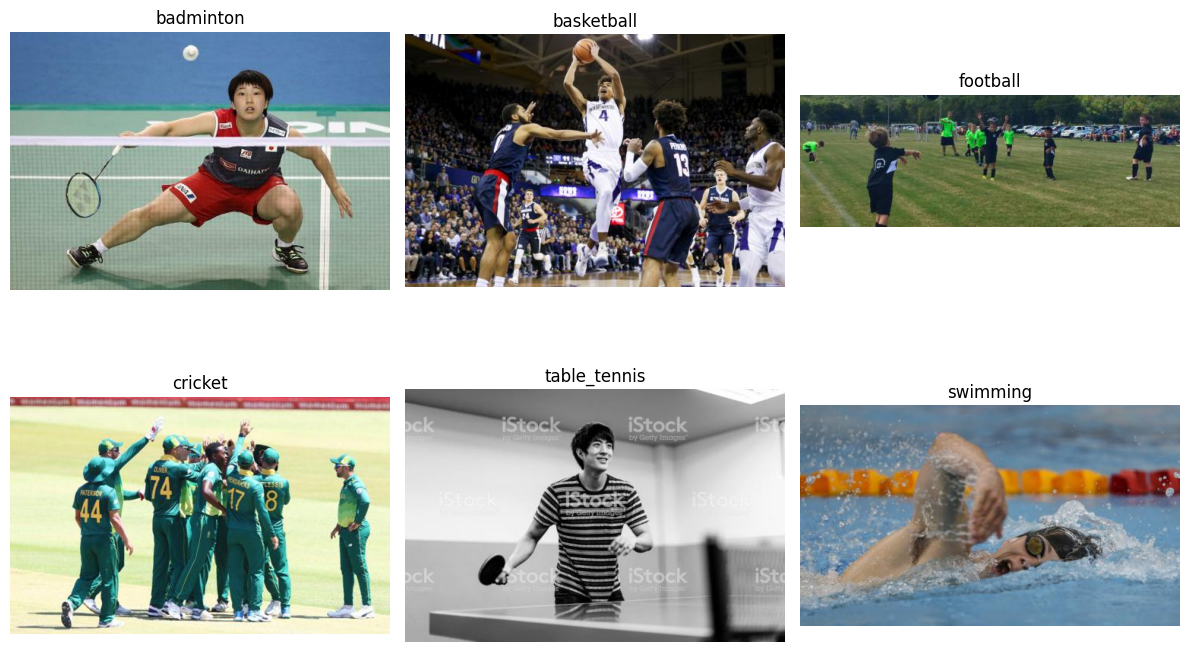

In [ ]:
# STEP 6: Display sample images from each class

import cv2
import random

plt.figure(figsize=(12, 8))

for i, class_name in enumerate(selected_classes[:6]):  # show 6 classes
    class_path = os.path.join(target_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Data Preprocessing and Dataset Splitting

## Train, Validation, and Test Split

The dataset is divided into training, validation, and testing subsets using a 70:15:15 ratio. This split ensures sufficient training data while maintaining separate datasets for validation and final model evaluation.

In [ ]:
# STEP 7: Split selected dataset into train, validation, and test sets

source_dir = "selected_dataset"
output_dir = "data"

if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

for class_name in selected_classes:
    class_path = os.path.join(source_dir, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    ]

    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    for split_name, split_imgs in {
        "train": train_imgs,
        "val": val_imgs,
        "test": test_imgs
    }.items():
        split_class_path = os.path.join(output_dir, split_name, class_name)
        os.makedirs(split_class_path, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_path, img)
            shutil.copy(src, dst)

print("Dataset split completed.")
print(os.listdir(output_dir))

Dataset split completed.
['test', 'train', 'val']


## Verification of Dataset Split

The number of images in the training, validation, and testing sets is verified to ensure the dataset was correctly divided before model training.

In [ ]:
# STEP 8: Verify train/val/test image counts

split_counts = []

for split in ["train", "val", "test"]:
    split_path = os.path.join("data", split)

    for class_name in selected_classes:
        class_path = os.path.join(split_path, class_name)

        images = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        ]

        split_counts.append({
            "Split": split,
            "Class": class_name,
            "Images": len(images)
        })

df_split_counts = pd.DataFrame(split_counts)

print(df_split_counts)

print("\nTotal per split:")
print(df_split_counts.groupby("Split")["Images"].sum())

    Split         Class  Images
0   train     badminton     641
1   train    basketball     336
2   train      football     543
3   train       cricket     459
4   train  table_tennis     487
5   train      swimming     472
6   train      shooting     366
7   train      formula1     467
8   train        boxing     486
9   train    volleyball     483
10  train         chess     327
11  train        hockey     391
12    val     badminton     138
13    val    basketball      72
14    val      football     116
15    val       cricket      98
16    val  table_tennis     104
17    val      swimming     101
18    val      shooting      78
19    val      formula1     100
20    val        boxing     104
21    val    volleyball     103
22    val         chess      70
23    val        hockey      84
24   test     badminton     138
25   test    basketball      73
26   test      football     117
27   test       cricket      99
28   test  table_tennis     105
29   test      swimming     102
30   tes

# Image Preprocessing and Data Augmentation

## Image Generators and Augmentation

Image generators are created for training, validation, and testing datasets. All images are resized to 224×224 pixels and normalized to improve model training stability. Data augmentation techniques such as rotation, zooming, and horizontal flipping are applied to the training data to improve generalization and reduce overfitting.

In [ ]:
# ============================================================
# Phase 3: Preprocessing and Data Augmentation
# Step 9: Create Image Generators
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "data/train"
val_dir = "data/val"
test_dir = "data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:")
print(train_generator.class_indices)

Found 5454 images belonging to 12 classes.
Found 1167 images belonging to 12 classes.
Found 1178 images belonging to 12 classes.
Class indices:
{'badminton': 0, 'basketball': 1, 'boxing': 2, 'chess': 3, 'cricket': 4, 'football': 5, 'formula1': 6, 'hockey': 7, 'shooting': 8, 'swimming': 9, 'table_tennis': 10, 'volleyball': 11}


## Corrupted Image Detection

The training dataset is checked for unreadable or corrupted image files to ensure data quality before model training.

In [ ]:
# Check unreadable/corrupted images in train folder

from PIL import Image

bad_files = []

for class_name in selected_classes:
    class_path = os.path.join("data/train", class_name)

    for file in os.listdir(class_path):
        file_path = os.path.join(class_path, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            bad_files.append(file_path)

print("Bad files found:", len(bad_files))
for f in bad_files:
    print(f)

Bad files found: 0


## File Format Analysis

The image file extensions are analyzed to identify the different image formats present in the dataset.

In [ ]:
# Check image extensions in selected dataset

from collections import Counter
import os

target_path = "/content/selected_dataset"

ext_counts = Counter()

for class_name in selected_classes:
    class_path = os.path.join(target_path, class_name)

    for file in os.listdir(class_path):
        ext = os.path.splitext(file)[1].lower()
        ext_counts[ext] += 1

print(ext_counts)

Counter({'.jpg': 7187, '.jpeg': 314, '.png': 296, '.ashx': 47, '.gif': 19, '.aspx': 17, '.php': 14, '.img': 5, '.webp': 5, '.cms': 4, '.5': 2, '.bmp': 2, '.bin': 1, '.axd': 1, '.asmx': 1, '.cls': 1})


## Removal of Unsupported Image Formats

Unsupported `.webp` image files are removed from the dataset to ensure compatibility with Keras image generators during model training.

In [ ]:
# Remove unsupported .webp files for Keras flow_from_directory

removed_files = []

for split in ["train", "val", "test"]:
    for class_name in selected_classes:
        class_path = os.path.join("data", split, class_name)

        for file in os.listdir(class_path):
            if file.lower().endswith(".webp"):
                file_path = os.path.join(class_path, file)
                os.remove(file_path)
                removed_files.append(file_path)

print("Removed unsupported .webp files:", len(removed_files))

Removed unsupported .webp files: 5


## Visualization of Augmented Images

Sample augmented training images are displayed to observe the effect of preprocessing and augmentation techniques applied during training.

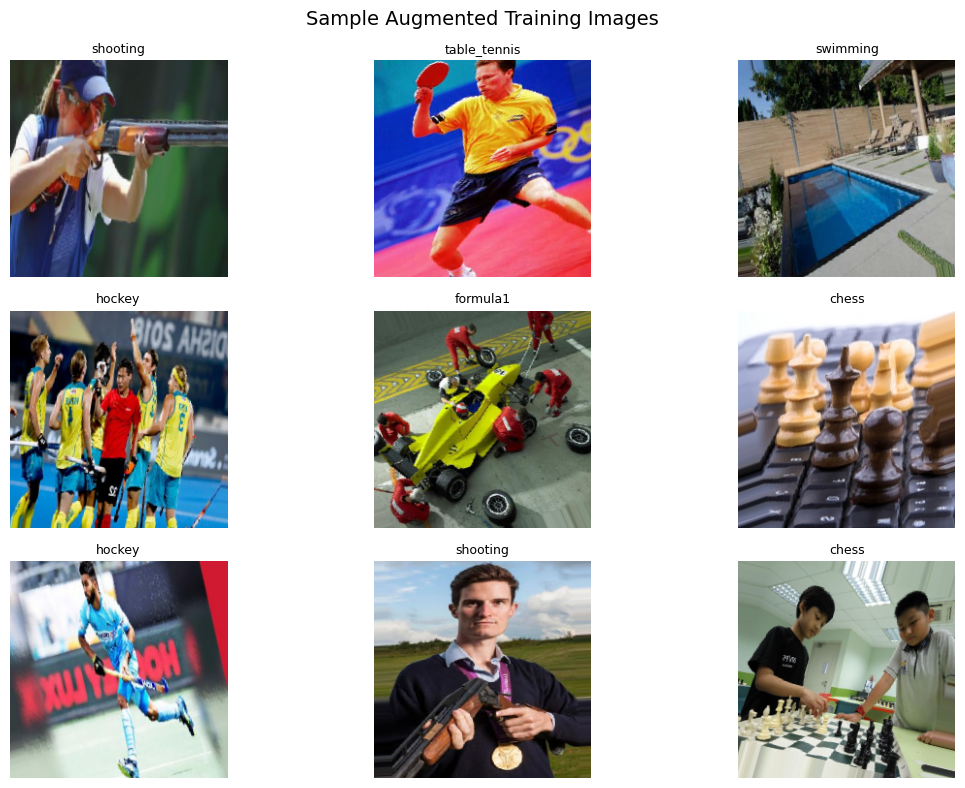

In [ ]:
# Get one real image batch from generator
batch_images, batch_labels = next(train_generator)

class_labels = list(train_generator.class_indices.keys())

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch_images[i])
    plt.title(class_labels[np.argmax(batch_labels[i])], fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images", fontsize=14)
plt.tight_layout()
plt.show()

# Baseline CNN Model

## Baseline CNN Architecture

A baseline Convolutional Neural Network (CNN) is designed for multi-class sports image classification. The architecture consists of three convolutional layers with MaxPooling, followed by three fully connected dense layers and a Softmax output layer for classification.

In [ ]:
# ============================================================
# Phase 4: Baseline CNN Model
# Step 11: Build Baseline CNN Architecture
# ============================================================

NUM_CLASSES = len(train_generator.class_indices)

baseline_model = models.Sequential([
    # Input Layer
    layers.Input(shape=(224, 224, 3)),

    # Convolution + Pooling Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution + Pooling Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Convolution + Pooling Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),

    # Output Layer
    layers.Dense(NUM_CLASSES, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,604 (85.02 MB)

 Trainable params: 22,286,604 (85.02 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Baseline CNN Model

## Baseline Model Training

The baseline CNN model is trained using the training dataset and validated on the validation dataset. Training time is also recorded to analyze computational efficiency and compare it with deeper architectures later in the project.

In [ ]:
# ============================================================
# Phase 5: Train Baseline CNN
# Step 12: Train Baseline Model
# ============================================================

EPOCHS = 20

baseline_start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

baseline_training_time = time.time() - baseline_start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")

Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 93s 497ms/step - accuracy: 0.3236 - loss: 2.0006 - val_accuracy: 0.3985 - val_loss: 1.7532
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 80s 468ms/step - accuracy: 0.4912 - loss: 1.5582 - val_accuracy: 0.5167 - val_loss: 1.5349
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 76s 442ms/step - accuracy: 0.5347 - loss: 1.4170 - val_accuracy: 0.5476 - val_loss: 1.4092
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 77s 448ms/step - accuracy: 0.5728 - loss: 1.3111 - val_accuracy: 0.5664 - val_loss: 1.3807
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 76s 444ms/step - accuracy: 0.5875 - loss: 1.2547 - val_accuracy: 0.5527 - val_loss: 1.3869
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 76s 444ms/step - accuracy: 0.6267 - loss: 1.1325 - val_accuracy: 0.6067 - val_loss: 1.2819
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 77s 453ms/step - accuracy: 0.6392 - loss: 1.0909 - val_accuracy: 0.6058 - val_loss: 1.2556
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 75s 441ms/step - accuracy: 0.6599 - loss: 1

## Training and Validation Performance Curves

The training and validation accuracy/loss curves are plotted to analyze the learning behavior of the baseline CNN model across epochs. These visualizations help identify issues such as overfitting or underfitting during training.

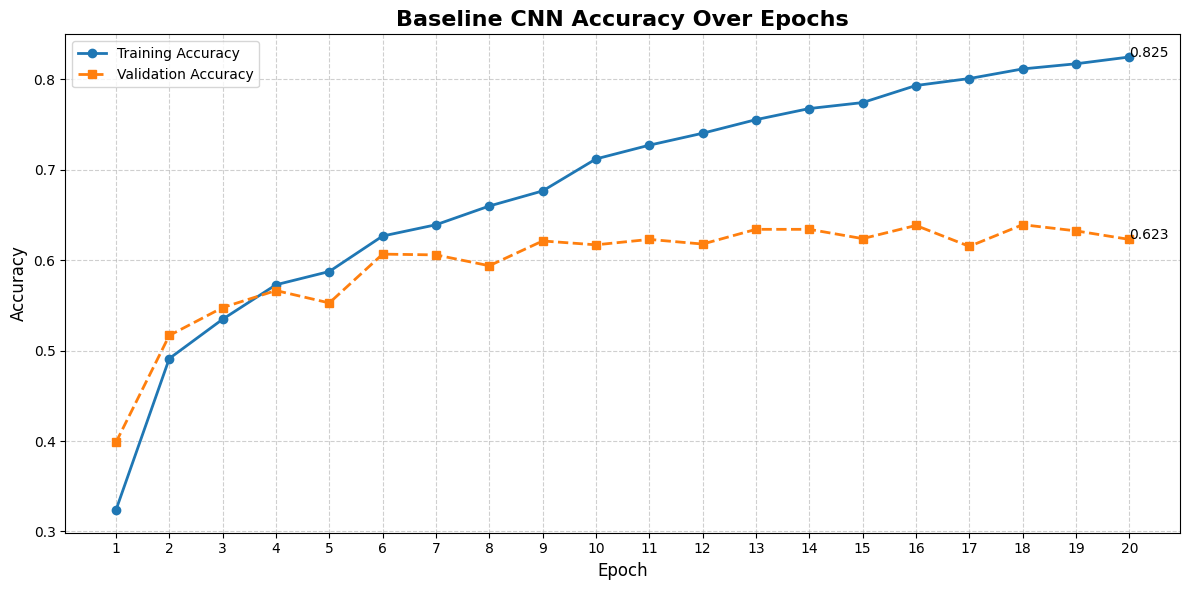

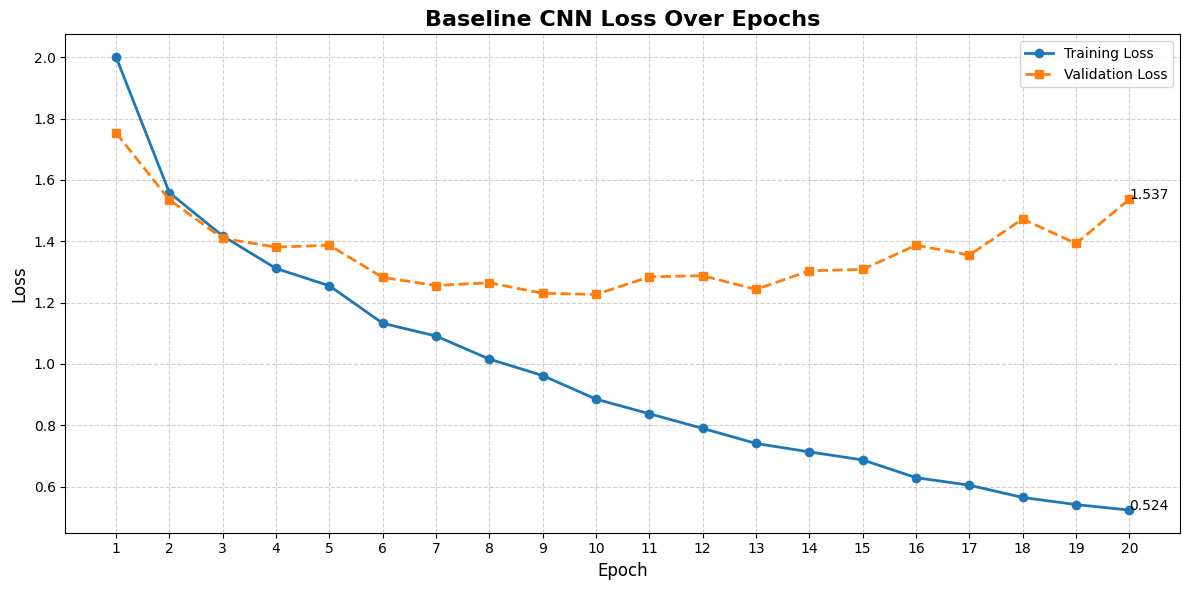

In [ ]:
# ============================================================
# Phase 5: Baseline Training Visualization
# Step 13: Plot Accuracy and Loss Curves
# ============================================================

import matplotlib.pyplot as plt

# Extract history
acc = baseline_history.history.get("accuracy", [])
val_acc = baseline_history.history.get("val_accuracy", [])
loss = baseline_history.history.get("loss", [])
val_loss = baseline_history.history.get("val_loss", [])

epochs_range = range(1, len(acc) + 1)

# Accuracy Plot

plt.figure(figsize=(12, 6))

plt.plot(epochs_range, acc, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="s", linewidth=2, linestyle="--", label="Validation Accuracy")

plt.title("Baseline CNN Accuracy Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last value 
if acc:
    plt.text(len(acc), acc[-1], f"{acc[-1]:.3f}", fontsize=10)
if val_acc:
    plt.text(len(val_acc), val_acc[-1], f"{val_acc[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

# Loss Plot
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs_range, val_loss, marker="s", linewidth=2, linestyle="--", label="Validation Loss")

plt.title("Baseline CNN Loss Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last value
if loss:
    plt.text(len(loss), loss[-1], f"{loss[-1]:.3f}", fontsize=10)
if val_loss:
    plt.text(len(val_loss), val_loss[-1], f"{val_loss[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

# Baseline Model Evaluation

## Evaluation on Test Dataset

The trained baseline CNN model is evaluated on the unseen test dataset to measure its generalization performance using accuracy and loss metrics.

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 14: Evaluate on Test Data
# ============================================================

test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.6070 - loss: 1.4563
Test Accuracy: 0.6070
Test Loss: 1.4563


## Generating Model Predictions

Predictions are generated on the test dataset to compare the model’s predicted classes with the actual class labels for further evaluation and analysis.

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 15: Generate Predictions
# ============================================================

test_generator.reset()

y_pred_prob = baseline_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print("Total test images:", len(y_true))
print("Total predictions:", len(y_pred_classes))
print("Class labels:", class_labels)

37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step
Total test images: 1178
Total predictions: 1178
Class labels: ['badminton', 'basketball', 'boxing', 'chess', 'cricket', 'football', 'formula1', 'hockey', 'shooting', 'swimming', 'table_tennis', 'volleyball']


## Classification Report

A classification report is generated to evaluate the baseline CNN model using precision, recall, F1-score, and overall accuracy for each sports category.

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 16: Classification Report
# ============================================================

print("Baseline CNN Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

Baseline CNN Classification Report:
              precision    recall  f1-score   support

   badminton       0.64      0.67      0.65       138
  basketball       0.56      0.33      0.41        73
      boxing       0.82      0.49      0.61       105
       chess       0.49      0.46      0.47        71
     cricket       0.61      0.68      0.64        99
    football       0.62      0.68      0.65       117
    formula1       0.65      0.69      0.67       101
      hockey       0.62      0.54      0.58        84
    shooting       0.41      0.66      0.51        79
    swimming       0.91      0.84      0.88       102
table_tennis       0.55      0.45      0.49       105
  volleyball       0.49      0.65      0.56       104

    accuracy                           0.61      1178
   macro avg       0.62      0.59      0.59      1178
weighted avg       0.63      0.61      0.61      1178



## Confusion Matrix Analysis

A normalized confusion matrix is used to visualize the classification performance of the baseline CNN model across all sports categories. It helps identify correctly classified classes and common misclassification patterns.

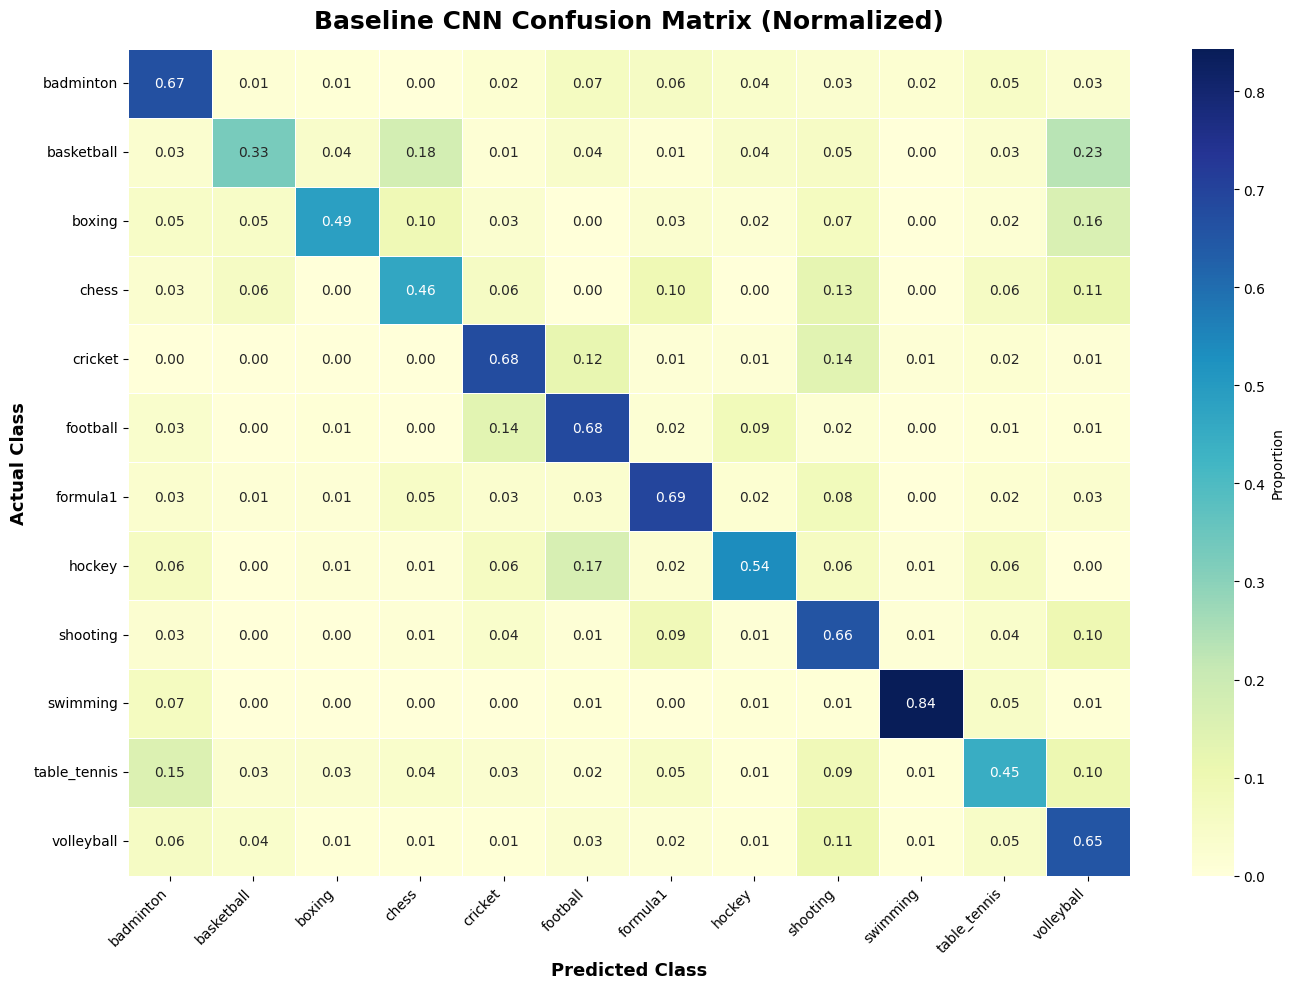

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 17: Confusion Matrix 
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Normalize (safe division)
cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("Baseline CNN Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## Sample Prediction Visualization

Sample predictions from the baseline CNN model are visualized to compare the actual and predicted sports classes. Correct predictions are highlighted in green, while incorrect predictions are highlighted in red.

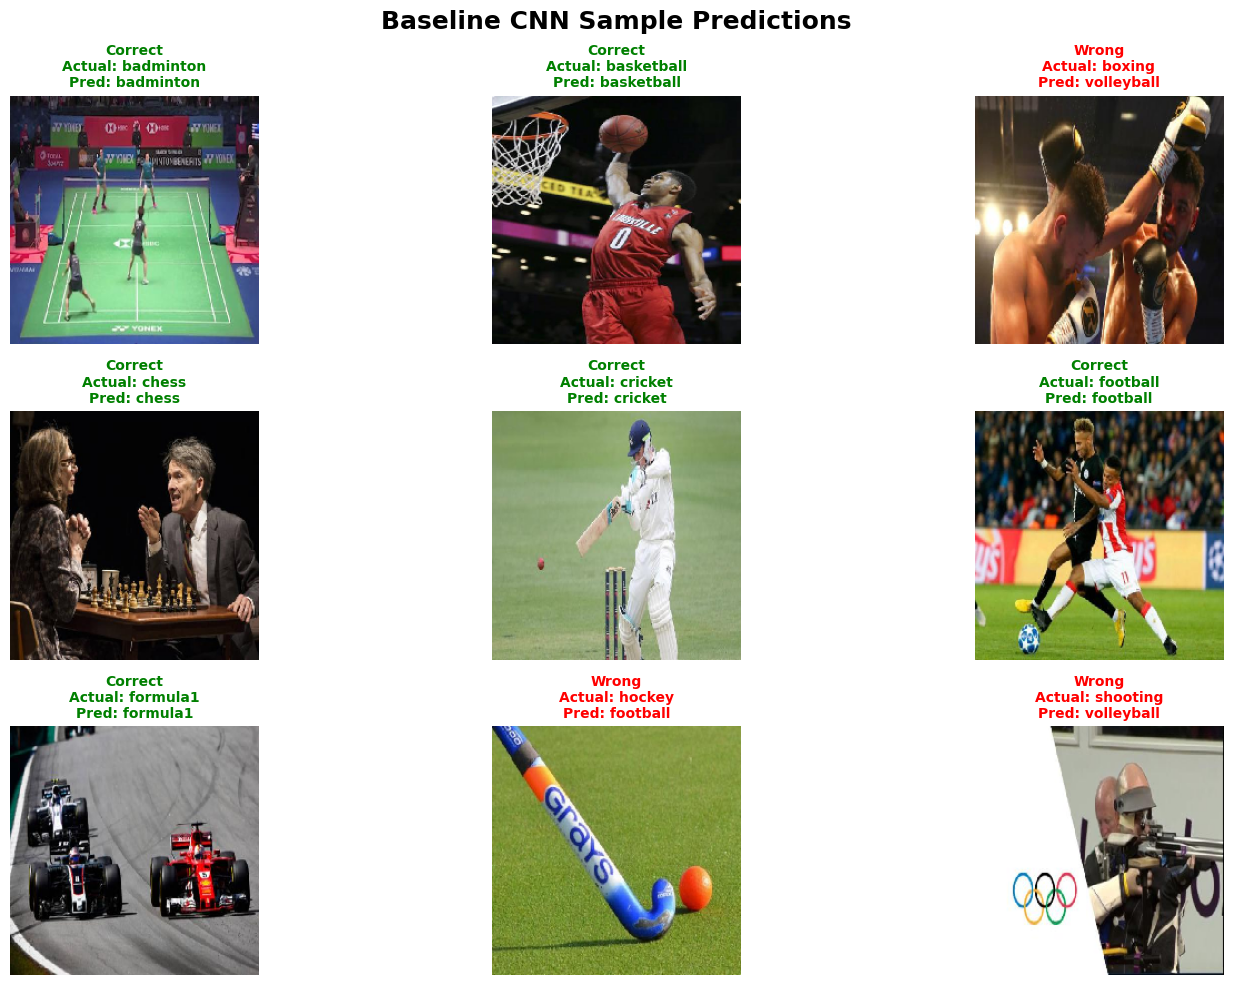

In [ ]:
# ============================================================
# Phase 6: Evaluation
# Step 18: Sample Predictions - Baseline CNN 
# ============================================================

test_generator.reset()

sample_images = []
sample_true_labels = []
sample_pred_labels = []

seen_classes = set()

for images, labels in test_generator:
    pred_probs = baseline_model.predict(images, verbose=0)
    pred_classes = np.argmax(pred_probs, axis=1)
    true_classes = np.argmax(labels, axis=1)

    for i in range(len(images)):
        true_label = class_labels[true_classes[i]]
        pred_label = class_labels[pred_classes[i]]

        # ensure diversity of classes
        if true_label not in seen_classes:
            sample_images.append(images[i])
            sample_true_labels.append(true_label)
            sample_pred_labels.append(pred_label)
            seen_classes.add(true_label)

        if len(sample_images) >= 9:
            break

    if len(sample_images) >= 9:
        break

plt.figure(figsize=(16, 10))

for i in range(len(sample_images)):
    is_correct = sample_true_labels[i] == sample_pred_labels[i]
    status = "Correct" if is_correct else "Wrong"
    title_color = "green" if is_correct else "red"

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])

    plt.title(
        f"{status}\nActual: {sample_true_labels[i]}\nPred: {sample_pred_labels[i]}",
        fontsize=10,
        color=title_color,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle(
    "Baseline CNN Sample Predictions",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Baseline CNN Performance Summary

### Evaluation Results

| Evaluation Metric | Performance |
|:---|:---|
| **Test Accuracy** | **60.70%** |
| **Test Loss** | **1.4563** |
| **Total Test Images Evaluated** | **1178** |
| **Total Sports Classes** | **12** |

### Key Observations

- The baseline CNN achieved a moderate classification accuracy of **60.70%** on the unseen test dataset.
- The model performed particularly well on visually distinctive classes such as **Swimming** with an F1-score of **0.88**.
- Lower performance was observed in classes such as **Basketball**, **Chess**, and **Table Tennis**, likely due to visual similarity and dataset complexity.
- Some confusion occurred between sports with similar visual patterns, backgrounds, or player movements.
- Although the baseline CNN successfully learned general image features, the results suggest that a deeper architecture with regularization may improve generalization performance.

### Conclusion

The baseline CNN model successfully demonstrated the ability of Convolutional Neural Networks to classify sports images across multiple categories. However, the moderate accuracy and misclassification patterns indicate that the model still suffers from limitations in feature extraction and generalization. Therefore, a deeper CNN architecture with additional layers and regularization techniques will be explored in the next phase to improve classification performance.

# Deeper CNN Model with Regularization

## Deeper CNN Architecture

A deeper CNN model is built to improve feature extraction compared to the baseline model. This architecture uses additional convolutional layers along with Batch Normalization and Dropout to improve training stability and reduce overfitting.

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Model
# Step 19: Build Deeper CNN with Batch Normalization and Dropout
# ============================================================

deep_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.40),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

deep_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,014,636 (99.24 MB)

 Trainable params: 26,013,228 (99.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

## Training the Deeper CNN Model

The deeper CNN model is trained using the augmented training dataset and validated on the validation dataset. Early stopping is applied to prevent overfitting and restore the best-performing model weights.

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Model
# Step 20: Train Deeper CNN Model
# ============================================================

EPOCHS = 20

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

deep_start_time = time.time()

deep_history = deep_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop]
)

deep_training_time = time.time() - deep_start_time

print(f"Deep CNN training time: {deep_training_time:.2f} seconds")

Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 136s 622ms/step - accuracy: 0.2690 - loss: 2.4170 - val_accuracy: 0.0900 - val_loss: 3.5732
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 486ms/step - accuracy: 0.3775 - loss: 1.9629 - val_accuracy: 0.2451 - val_loss: 2.9147
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 485ms/step - accuracy: 0.4349 - loss: 1.7322 - val_accuracy: 0.4567 - val_loss: 1.6150
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 85s 496ms/step - accuracy: 0.4817 - loss: 1.6056 - val_accuracy: 0.4953 - val_loss: 1.5322
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 84s 491ms/step - accuracy: 0.5161 - loss: 1.4991 - val_accuracy: 0.4979 - val_loss: 1.5847
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 486ms/step - accuracy: 0.5288 - loss: 1.4395 - val_accuracy: 0.5099 - val_loss: 1.4854
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 84s 494ms/step - accuracy: 0.5565 - loss: 1.3933 - val_accuracy: 0.5510 - val_loss: 1.3645
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 141s 488ms/step - accuracy: 0.5717 - loss:

## Training and Validation Curves for Deep CNN

The training and validation accuracy/loss curves are plotted to analyze the learning performance of the deeper CNN model across epochs and compare its behavior with the baseline CNN.

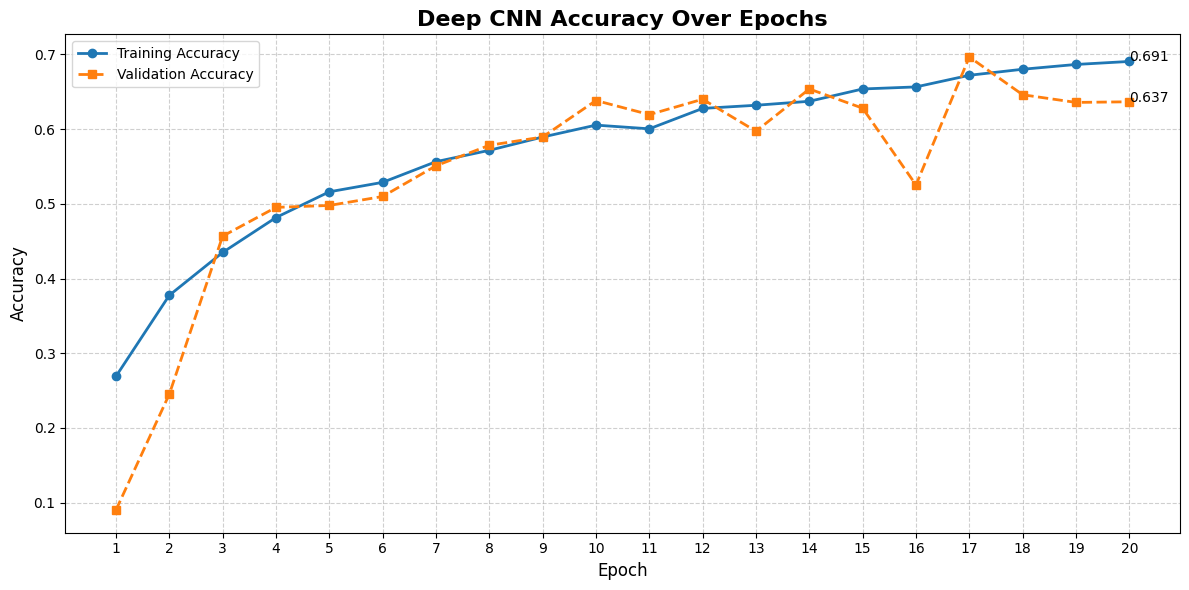

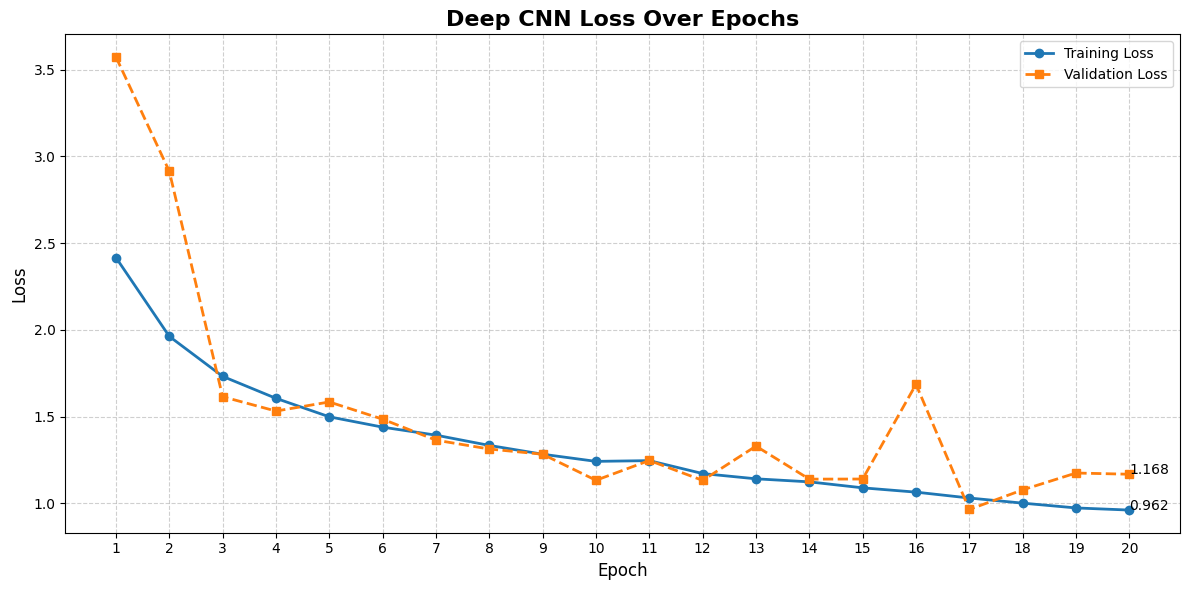

In [ ]:
# ============================================================
# Phase 7: Deep CNN Visualization
# ============================================================

import matplotlib.pyplot as plt

# Extract history safely
acc = deep_history.history.get("accuracy", [])
val_acc = deep_history.history.get("val_accuracy", [])
loss = deep_history.history.get("loss", [])
val_loss = deep_history.history.get("val_loss", [])

epochs_range = range(1, len(acc) + 1)

# Accuracy Plot
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, acc, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="s", linewidth=2, linestyle="--", label="Validation Accuracy")

plt.title("Deep CNN Accuracy Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last values
if acc:
    plt.text(len(acc), acc[-1], f"{acc[-1]:.3f}", fontsize=10)
if val_acc:
    plt.text(len(val_acc), val_acc[-1], f"{val_acc[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

# Loss Plot
plt.figure(figsize=(12, 6))

plt.plot(epochs_range, loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs_range, val_loss, marker="s", linewidth=2, linestyle="--", label="Validation Loss")

plt.title("Deep CNN Loss Over Epochs", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.xticks(epochs_range)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate last values
if loss:
    plt.text(len(loss), loss[-1], f"{loss[-1]:.3f}", fontsize=10)
if val_loss:
    plt.text(len(val_loss), val_loss[-1], f"{val_loss[-1]:.3f}", fontsize=10)

plt.tight_layout()
plt.show()

# Deeper CNN Model Evaluation

## Evaluation on Test Dataset

The deeper CNN model is evaluated on the unseen test dataset to measure its classification performance, generalization capability, and computational efficiency.

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 22: Evaluate Deep CNN on Test Data
# ============================================================

print("=" * 70)
print("Evaluating Deep CNN on Test Dataset")
print("=" * 70)

deep_test_loss, deep_test_accuracy = deep_model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("DEEP CNN TEST PERFORMANCE")
print("=" * 70)
print(f"Test Accuracy      : {deep_test_accuracy:.4f}")
print(f"Test Loss          : {deep_test_loss:.4f}")
print(f"Training Time (sec): {deep_training_time:.2f}")
print(f"Training Time (min): {deep_training_time / 60:.2f}")
print("=" * 70)

Evaluating Deep CNN on Test Dataset
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step - accuracy: 0.6876 - loss: 0.9976
DEEP CNN TEST PERFORMANCE
Test Accuracy      : 0.6876
Test Loss          : 0.9976
Training Time (sec): 1788.68
Training Time (min): 29.81


## Generating Predictions for Deep CNN

Predictions are generated using the deeper CNN model on the test dataset to compare predicted labels with the actual class labels for detailed performance analysis.

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 23: Generate Predictions
# ============================================================

import numpy as np

# Reset generator to ensure correct ordering
test_generator.reset()

# Predict
deep_pred_prob = deep_model.predict(
    test_generator,
    verbose=1
)

deep_pred_classes = np.argmax(deep_pred_prob, axis=1)

# True labels
y_true = test_generator.classes

# Class labels
class_labels = list(test_generator.class_indices.keys())

print("=" * 70)
print("DEEP CNN PREDICTION SUMMARY")
print("=" * 70)
print("Total Test Images :", len(y_true))
print("Total Predictions :", len(deep_pred_classes))
print("Number of Classes :", len(class_labels))
print("Class Labels      :", class_labels)
print("=" * 70)

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 178ms/step
DEEP CNN PREDICTION SUMMARY
Total Test Images : 1178
Total Predictions : 1178
Number of Classes : 12
Class Labels      : ['badminton', 'basketball', 'boxing', 'chess', 'cricket', 'football', 'formula1', 'hockey', 'shooting', 'swimming', 'table_tennis', 'volleyball']


## Classification Report for Deep CNN

A detailed classification report is generated to evaluate the deeper CNN model using precision, recall, F1-score, and overall accuracy for each sports category.

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 24: Classification Report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd

print("=" * 70)
print("DEEP CNN CLASSIFICATION REPORT")
print("=" * 70)

deep_report_dict = classification_report(
    y_true,
    deep_pred_classes,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

deep_report_df = pd.DataFrame(deep_report_dict).transpose()
print(deep_report_df.round(4))

print("=" * 70)

DEEP CNN CLASSIFICATION REPORT
              precision  recall  f1-score    support
badminton        0.7456  0.6159    0.6746   138.0000
basketball       0.7778  0.4795    0.5932    73.0000
boxing           0.7232  0.7714    0.7465   105.0000
chess            0.6731  0.4930    0.5691    71.0000
cricket          0.6827  0.7172    0.6995    99.0000
football         0.6689  0.8462    0.7472   117.0000
formula1         0.6364  0.8317    0.7210   101.0000
hockey           0.6923  0.5357    0.6040    84.0000
shooting         0.6618  0.5696    0.6122    79.0000
swimming         0.8033  0.9608    0.8750   102.0000
table_tennis     0.7286  0.4857    0.5829   105.0000
volleyball       0.5548  0.7788    0.6480   104.0000
accuracy         0.6876  0.6876    0.6876     0.6876
macro avg        0.6957  0.6738    0.6728  1178.0000
weighted avg     0.6962  0.6876    0.6805  1178.0000


## Confusion Matrix for Deep CNN

A normalized confusion matrix is used to visualize the classification performance of the deeper CNN model and identify improvements or remaining misclassification patterns across sports categories.

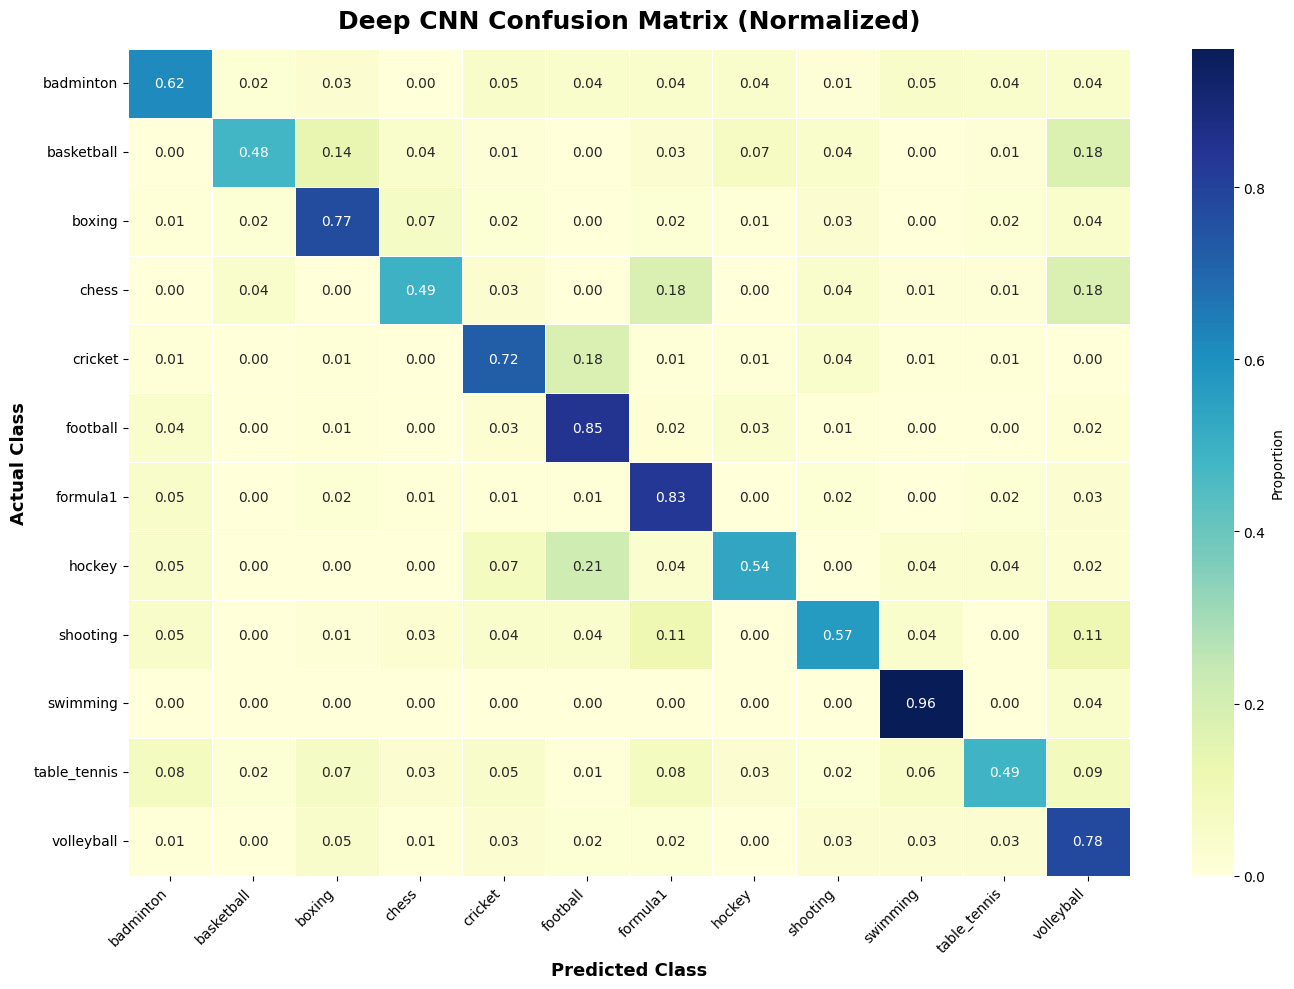

In [ ]:
# ============================================================
# Phase 7: Deeper CNN Evaluation
# Step 25: Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm_deep = confusion_matrix(y_true, deep_pred_classes)

# Normalize
cm_deep_norm = cm_deep.astype('float') / np.maximum(cm_deep.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_deep_norm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("Deep CNN Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Comparative Analysis of CNN Architectures

## Baseline CNN vs Deep CNN Performance Comparison

The performance of the baseline CNN and deeper CNN models is compared using training accuracy, validation accuracy, test accuracy, test loss, and training time to analyze the impact of deeper architecture and regularization techniques.

In [ ]:
# ============================================================
# Phase 7: Baseline vs Deep CNN Comparison
# Step 26: Performance Comparison Table
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline CNN", "Deep CNN"],
    "Train Accuracy": [
        max(baseline_history.history.get("accuracy", [0])),
        max(deep_history.history.get("accuracy", [0]))
    ],
    "Validation Accuracy": [
        max(baseline_history.history.get("val_accuracy", [0])),
        max(deep_history.history.get("val_accuracy", [0]))
    ],
    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy
    ],
    "Test Loss": [
        test_loss,
        deep_test_loss
    ],
    "Training Time (sec)": [
        baseline_training_time,
        deep_training_time
    ]
})

comparison = comparison.round({
    "Train Accuracy": 4,
    "Validation Accuracy": 4,
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best test accuracy
comparison = comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON (BASELINE vs DEEP CNN)")
print("=" * 70)

comparison

MODEL PERFORMANCE COMPARISON (BASELINE vs DEEP CNN)


,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Test Loss,Training Time (sec)
0,Deep CNN,0.6907,0.6967,0.6876,0.9976,1788.68
1,Baseline CNN,0.8247,0.6392,0.6070,1.4563,1552.83


## Visual Performance Comparison

The performance metrics of the baseline CNN and deeper CNN models are visualized to compare their training accuracy, validation accuracy, and test accuracy more clearly.

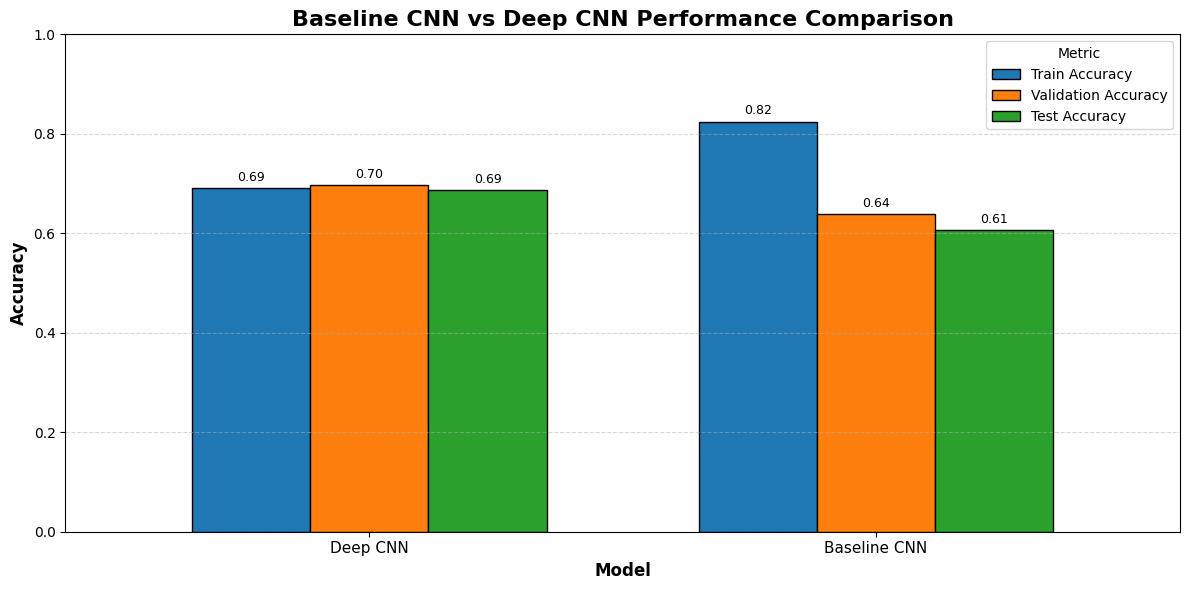

In [ ]:
# ============================================================
# Phase 7: Baseline vs Deep CNN Comparison
# Step 27: Visual Comparison
# ============================================================

import matplotlib.pyplot as plt

metrics_to_plot = ["Train Accuracy", "Validation Accuracy", "Test Accuracy"]

comparison_plot = comparison.set_index("Model")[metrics_to_plot]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.7,
    edgecolor="black"
)

plt.title("Baseline CNN vs Deep CNN Performance Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")

plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=10)

plt.legend(title="Metric", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

## Deep CNN Performance Summary

### Evaluation Results

| Evaluation Metric | Result |
|:---|:---|
| **Test Accuracy** | **68.76%** |
| **Test Loss** | **0.9976** |
| **Training Time** | **29.81 minutes** |
| **Total Test Images** | **1178** |

### Model Comparison

| Model | Test Accuracy | Test Loss |
|:---|:---|:---|
| **Deep CNN** | **68.76%** | **0.9976** |
| **Baseline CNN** | **60.70%** | **1.4563** |

### Key Observations

- The Deep CNN model achieved better performance than the Baseline CNN.
- Test accuracy improved from **60.70%** to **68.76%**.
- Batch Normalization and Dropout helped reduce overfitting and improve generalization.
- Strong performance was observed in classes such as **Swimming**, **Football**, and **Formula1**.
- Some confusion still existed between visually similar sports categories.

### Conclusion

The deeper CNN architecture improved overall classification performance and generalization compared to the baseline CNN. The addition of extra convolutional layers and regularization techniques allowed the model to learn more robust image features, although it required higher training time and computational cost.

# Optimizer Experimentation

## Deep CNN with SGD Optimizer

To analyze the impact of different optimizers on model performance, the deeper CNN architecture is retrained using the Stochastic Gradient Descent (SGD) optimizer with momentum. The results will later be compared with the Adam optimizer.

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 28: Build Deep CNN with SGD Optimizer
# ============================================================

from tensorflow.keras.optimizers import SGD

deep_model_sgd = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    # Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.45),

    # Classifier
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.40),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile with SGD
deep_model_sgd.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("DEEP CNN WITH SGD OPTIMIZER")
print("=" * 70)
print("Optimizer : SGD")
print("Learning Rate : 0.01")
print("Momentum : 0.9")
print("=" * 70)

deep_model_sgd.summary()

DEEP CNN WITH SGD OPTIMIZER
Optimizer : SGD
Learning Rate : 0.01
Momentum : 0.9


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 686,252 (2.62 MB)

 Trainable params: 684,332 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Training Deep CNN with SGD

The deeper CNN model is trained using the SGD optimizer to evaluate its convergence speed, stability, and classification performance compared to the Adam optimizer.

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 29: Train Deep CNN with SGD Optimizer
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping
import time

EPOCHS_SGD = 20

early_stop_sgd = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("TRAINING DEEP CNN WITH SGD OPTIMIZER")
print("=" * 70)

sgd_start_time = time.time()

sgd_history = deep_model_sgd.fit(
    train_generator,
    epochs=EPOCHS_SGD,
    validation_data=val_generator,
    callbacks=[early_stop_sgd],
    verbose=1
)

sgd_training_time = time.time() - sgd_start_time

print("=" * 70)
print("SGD MODEL TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time (sec): {sgd_training_time:.2f}")
print(f"Training Time (min): {sgd_training_time / 60:.2f}")
print("=" * 70)

TRAINING DEEP CNN WITH SGD OPTIMIZER
Epoch 1/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 107s 544ms/step - accuracy: 0.2451 - loss: 2.4486 - val_accuracy: 0.2716 - val_loss: 2.3510
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 488ms/step - accuracy: 0.3343 - loss: 1.9945 - val_accuracy: 0.3685 - val_loss: 1.8976
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 485ms/step - accuracy: 0.3625 - loss: 1.9032 - val_accuracy: 0.2734 - val_loss: 2.1297
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 475ms/step - accuracy: 0.3638 - loss: 1.8611 - val_accuracy: 0.3599 - val_loss: 1.8845
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 84s 489ms/step - accuracy: 0.3990 - loss: 1.8094 - val_accuracy: 0.4473 - val_loss: 1.6499
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 480ms/step - accuracy: 0.4191 - loss: 1.7486 - val_accuracy: 0.3342 - val_loss: 2.0630
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 482ms/step - accuracy: 0.4226 - loss: 1.7422 - val_accuracy: 0.4567 - val_loss: 1.6232
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 4

## Evaluation of SGD Optimized Model

The Deep CNN model trained with the SGD optimizer is evaluated on the test dataset to compare its performance and training efficiency with the Adam optimizer.

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 30: Evaluate SGD Model on Test Data
# ============================================================

print("=" * 70)
print("Evaluating Deep CNN (SGD) on Test Dataset")
print("=" * 70)

sgd_test_loss, sgd_test_accuracy = deep_model_sgd.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("SGD MODEL TEST PERFORMANCE")
print("=" * 70)
print(f"Test Accuracy      : {sgd_test_accuracy:.4f}")
print(f"Test Loss          : {sgd_test_loss:.4f}")
print(f"Training Time (sec): {sgd_training_time:.2f}")
print(f"Training Time (min): {sgd_training_time / 60:.2f}")
print("=" * 70)

Evaluating Deep CNN (SGD) on Test Dataset
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step - accuracy: 0.5170 - loss: 1.3943
SGD MODEL TEST PERFORMANCE
Test Accuracy      : 0.5170
Test Loss          : 1.3943
Training Time (sec): 1720.03
Training Time (min): 28.67


## Optimizer Performance Comparison

The performance of the Adam and SGD optimizers is compared using test accuracy, test loss, and training time to analyze their impact on model convergence and classification performance.

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment (Adam vs SGD)
# Step 31: Optimizer Comparison Table
# ============================================================

import pandas as pd

optimizer_comparison = pd.DataFrame({
    "Optimizer": ["Adam", "SGD"],
    "Test Accuracy": [deep_test_accuracy, sgd_test_accuracy],
    "Test Loss": [deep_test_loss, sgd_test_loss],
    "Training Time (sec)": [deep_training_time, sgd_training_time]
})

optimizer_comparison = optimizer_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

optimizer_comparison = optimizer_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("OPTIMIZER COMPARISON (ADAM vs SGD)")
print("=" * 70)

optimizer_comparison

OPTIMIZER COMPARISON (ADAM vs SGD)


,Optimizer,Test Accuracy,Test Loss,Training Time (sec)
0,Adam,0.6876,0.9976,1788.68
1,SGD,0.5170,1.3943,1720.03


## Visualization of Optimizer Performance

The test accuracy of the Adam and SGD optimizers is visualized to compare their effectiveness in training the deeper CNN model.

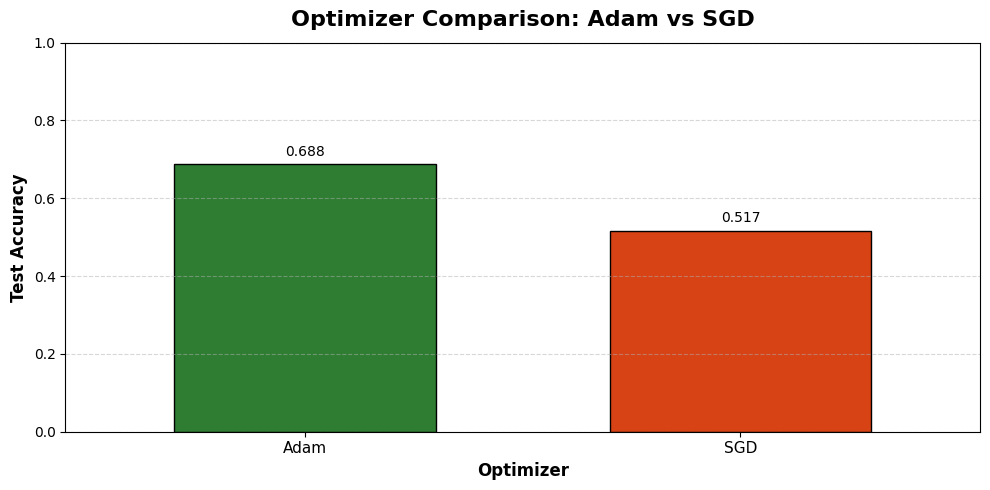

In [ ]:
# ============================================================
# Phase 8: Optimizer Experiment
# Step 32: Optimizer Performance Visualization 
# ============================================================

import matplotlib.pyplot as plt

ax = optimizer_comparison.set_index("Optimizer")["Test Accuracy"].plot(
    kind="bar",
    color=["#2E7D32", "#D84315"],
    figsize=(10, 5),
    width=0.6,
    edgecolor="black"
)

plt.title("Optimizer Comparison: Adam vs SGD", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Optimizer", fontsize=12, fontweight="bold")
plt.ylabel("Test Accuracy", fontsize=12, fontweight="bold")

plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=10)

plt.tight_layout()
plt.show()

## Optimizer Performance Summary

### Optimizer Comparison Results

| Optimizer | Test Accuracy | Test Loss | Training Time |
|:---|:---|:---|:---|
| **Adam** | **68.76%** | **0.9976** | **29.81 min** |
| **SGD** | **51.70%** | **1.3943** | **28.67 min** |

### Key Observations

- The Adam optimizer significantly outperformed SGD in terms of test accuracy and loss.
- Adam achieved faster and more stable convergence during training.
- SGD showed slower learning and lower classification performance on the sports image dataset.
- Although both optimizers required similar training time, Adam produced much better generalization performance.

### Conclusion

The experimental results indicate that the Adam optimizer is more effective for this image classification task compared to SGD. Adam’s adaptive learning mechanism allowed the deeper CNN model to converge more efficiently and achieve higher classification accuracy.

# Ablation Study

## Deep CNN Without Dropout

An ablation study is performed by removing the Dropout layers from the deeper CNN architecture while keeping all other layers unchanged. This experiment helps analyze the contribution of Dropout regularization to model performance and generalization.

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 33: Build Deep CNN WITHOUT Dropout
# ============================================================

deep_model_no_dropout = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4 (same as deep model)
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classifier (NO Dropout)
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

deep_model_no_dropout.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("ABLATION MODEL: DEEP CNN WITHOUT DROPOUT")
print("=" * 70)
print("Only Dropout removed — all other layers unchanged")
print("=" * 70)

deep_model_no_dropout.summary()

ABLATION MODEL: DEEP CNN WITHOUT DROPOUT
Only Dropout removed — all other layers unchanged


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,02

 Total params: 686,252 (2.62 MB)

 Trainable params: 684,332 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

## Training the Ablation Model

The Deep CNN model without Dropout regularization is trained to evaluate how the removal of Dropout affects model learning, overfitting, and overall classification performance.

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 34: Train Deep CNN WITHOUT Dropout
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS_ABLATION = 10

early_stop_no_dropout = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("TRAINING ABLATION MODEL: DEEP CNN WITHOUT DROPOUT")
print("=" * 70)

no_dropout_start = time.time()

history_no_dropout = deep_model_no_dropout.fit(
    train_generator,
    epochs=EPOCHS_ABLATION,
    validation_data=val_generator,
    callbacks=[early_stop_no_dropout],
    verbose=1
)

no_dropout_time = time.time() - no_dropout_start

print("=" * 70)
print("NO DROPOUT ABLATION MODEL TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time (sec): {no_dropout_time:.2f}")
print(f"Training Time (min): {no_dropout_time / 60:.2f}")
print("=" * 70)

TRAINING ABLATION MODEL: DEEP CNN WITHOUT DROPOUT
Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 101s 518ms/step - accuracy: 0.3894 - loss: 1.8701 - val_accuracy: 0.1011 - val_loss: 3.4812
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 85s 496ms/step - accuracy: 0.4688 - loss: 1.6050 - val_accuracy: 0.2614 - val_loss: 2.6105
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 84s 493ms/step - accuracy: 0.5189 - loss: 1.4559 - val_accuracy: 0.3993 - val_loss: 1.9066
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 479ms/step - accuracy: 0.5359 - loss: 1.3788 - val_accuracy: 0.5064 - val_loss: 1.4747
Epoch 5/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 473ms/step - accuracy: 0.5664 - loss: 1.3124 - val_accuracy: 0.4516 - val_loss: 1.9991
Epoch 6/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 479ms/step - accuracy: 0.5933 - loss: 1.2501 - val_accuracy: 0.4593 - val_loss: 1.9739
Epoch 7/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 485ms/step - accuracy: 0.6049 - loss: 1.1928 - val_accuracy: 0.5878 - val_loss: 1.3233
Epoch 8/10
171/171 ━━━━━━━━━━━━━

## Evaluation of the Ablation Model

The Deep CNN model without Dropout is evaluated on the test dataset to analyze the effect of removing Dropout regularization on classification performance and generalization ability.

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 35: Evaluate Deep CNN WITHOUT Dropout
# ============================================================

print("=" * 70)
print("Evaluating Ablation Model: Deep CNN WITHOUT Dropout")
print("=" * 70)

no_dropout_loss, no_dropout_accuracy = deep_model_no_dropout.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("NO DROPOUT MODEL TEST PERFORMANCE")
print("=" * 70)
print(f"Test Accuracy      : {no_dropout_accuracy:.4f}")
print(f"Test Loss          : {no_dropout_loss:.4f}")
print(f"Training Time (sec): {no_dropout_time:.2f}")
print(f"Training Time (min): {no_dropout_time / 60:.2f}")
print("=" * 70)

Evaluating Ablation Model: Deep CNN WITHOUT Dropout
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.6375 - loss: 1.1288
NO DROPOUT MODEL TEST PERFORMANCE
Test Accuracy      : 0.6375
Test Loss          : 1.1288
Training Time (sec): 843.83
Training Time (min): 14.06


## Dropout Ablation Comparison

The performance of the Deep CNN model with and without Dropout regularization is compared to evaluate the importance of Dropout in reducing overfitting and improving model generalization.

In [ ]:
# ============================================================
# Phase 8: Ablation Study
# Step 36: Dropout Ablation Comparison
# ============================================================

ablation_comparison = pd.DataFrame({
    "Model": ["Deep CNN with Dropout", "Deep CNN without Dropout"],
    "Test Accuracy": [deep_test_accuracy, no_dropout_accuracy],
    "Test Loss": [deep_test_loss, no_dropout_loss],
    "Training Time (sec)": [deep_training_time, no_dropout_time]
})

ablation_comparison = ablation_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

print("=" * 70)
print("DROPOUT ABLATION COMPARISON")
print("=" * 70)

ablation_comparison

DROPOUT ABLATION COMPARISON


,Model,Test Accuracy,Test Loss,Training Time (sec)
0,Deep CNN with Dropout,0.6876,0.9976,1788.68
1,Deep CNN without Dropout,0.6375,1.1288,843.83


## Ablation Study Summary

### Dropout Ablation Results

| Model | Test Accuracy | Test Loss | Training Time |
|:---|:---|:---|:---|
| **Deep CNN with Dropout** | **68.76%** | **0.9976** | **29.81 min** |
| **Deep CNN without Dropout** | **63.75%** | **1.1288** | **14.06 min** |

### Key Observations

- Removing Dropout reduced the overall classification accuracy of the Deep CNN model.
- The model without Dropout showed higher test loss, indicating weaker generalization performance.
- Dropout regularization helped prevent overfitting by improving the model’s ability to generalize on unseen test data.
- Although the model without Dropout trained faster, its classification performance was lower.

### Conclusion

The ablation study demonstrates that Dropout regularization plays an important role in improving the performance and generalization ability of the Deep CNN model. The Deep CNN with Dropout achieved better accuracy and lower loss, confirming the effectiveness of regularization techniques in deep learning models.

# Final Comparative Analysis

## Final Model Performance Comparison

The performance of all CNN models developed in this project is compared using test accuracy, test loss, and training time to identify the most effective architecture and training strategy.

In [ ]:
# ============================================================
# Phase 8: Final Model Comparison Table
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN (Adam)",
        "Deep CNN (SGD)",
        "Deep CNN (No Dropout)"
    ],
    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy,
        sgd_test_accuracy,
        no_dropout_accuracy
    ],
    "Test Loss": [
        test_loss,
        deep_test_loss,
        sgd_test_loss,
        no_dropout_loss
    ],
    "Training Time (sec)": [
        baseline_training_time,
        deep_training_time,
        sgd_training_time,
        no_dropout_time
    ]
})

# Clean formatting
final_comparison = final_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best accuracy
final_comparison = final_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL MODEL PERFORMANCE COMPARISON (PHASE 8)")
print("=" * 70)

final_comparison

FINAL MODEL PERFORMANCE COMPARISON (PHASE 8)


,Model,Test Accuracy,Test Loss,Training Time (sec)
0,Deep CNN (Adam),0.6876,0.9976,1788.68
1,Deep CNN (No Dropout),0.6375,1.1288,843.83
2,Baseline CNN,0.6070,1.4563,1552.83
3,Deep CNN (SGD),0.5170,1.3943,1720.03


## Final Comparative Analysis

### Final Model Comparison

| Model | Test Accuracy | Test Loss |
|:---|:---|:---|
| **Deep CNN (Adam)** | **68.76%** | **0.9976** |
| **Deep CNN (No Dropout)** | **63.75%** | **1.1288** |
| **Baseline CNN** | **60.70%** | **1.4563** |
| **Deep CNN (SGD)** | **51.70%** | **1.3943** |

### Key Observations

- Deep CNN with Adam achieved the highest classification accuracy.
- Dropout regularization improved model generalization performance.
- The deeper architecture outperformed the baseline CNN.
- SGD produced the lowest accuracy among all models.

### Conclusion

The Deep CNN with Adam optimizer achieved the best overall performance among all models trained from scratch. The results show that deeper architectures and regularization techniques improve image classification performance and generalization ability.

# Transfer Learning with MobileNetV2

## Building the Transfer Learning Model

MobileNetV2, pre-trained on ImageNet, is used as a feature extractor for the sports image classification task. The original classification head is removed, the pretrained base is frozen, and a custom dense classification head is added for the 12 sports classes.

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 37: Build MobileNetV2 Transfer Learning Model
# ============================================================

from tensorflow.keras import models, layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained base model
base_model.trainable = False

# Build transfer learning model
transfer_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Convert generator images from [0, 1] back to [0, 255]
    # before applying MobileNetV2 preprocessing
    layers.Rescaling(255.0),
    layers.Lambda(preprocess_input),

    # Pretrained feature extractor
    base_model,

    # Custom classification head
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
transfer_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("PHASE 9: TRANSFER LEARNING MODEL")
print("=" * 70)
print("Base Model      : MobileNetV2")
print("Weights         : ImageNet")
print("Input Shape     : 224 x 224 x 3")
print("Base Trainable  : False")
print("Strategy        : Feature Extraction")
print("Optimizer       : Adam")
print("Loss Function   : Categorical Crossentropy")
print("=" * 70)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
PHASE 9: TRANSFER LEARNING MODEL
Base Model      : MobileNetV2
Weights         : ImageNet
Input Shape     : 224 x 224 x 3
Base Trainable  : False
Strategy        : Feature Extraction
Optimizer       : Adam
Loss Function   : Categorical Crossentropy


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,004 (9.88 MB)

 Trainable params: 331,020 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Training the Transfer Learning Model

The MobileNetV2 transfer learning model is trained using a frozen pretrained base and a custom classification head. Early stopping is applied to prevent overfitting and restore the best model weights.

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 38: Train MobileNetV2 Transfer Learning Model
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS_TRANSFER = 10

# Early stopping prevents overfitting and restores the best model weights
early_stop_transfer = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("PHASE 9: TRAINING TRANSFER LEARNING MODEL")
print("=" * 70)
print("Model           : MobileNetV2")
print("Strategy        : Frozen Base Feature Extraction")
print(f"Max Epochs      : {EPOCHS_TRANSFER}")
print("Early Stopping  : Monitor val_loss, patience=3")
print("=" * 70)

transfer_start_time = time.time()

transfer_history = transfer_model.fit(
    train_generator,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_generator,
    callbacks=[early_stop_transfer],
    verbose=1
)

transfer_training_time = time.time() - transfer_start_time

print("=" * 70)
print("TRANSFER LEARNING TRAINING COMPLETED")
print("=" * 70)
print(f"Training Time (sec): {transfer_training_time:.2f}")
print(f"Training Time (min): {transfer_training_time / 60:.2f}")
print("=" * 70)

PHASE 9: TRAINING TRANSFER LEARNING MODEL
Model           : MobileNetV2
Strategy        : Frozen Base Feature Extraction
Max Epochs      : 10
Early Stopping  : Monitor val_loss, patience=3
Epoch 1/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 78s 454ms/step - accuracy: 0.9246 - loss: 0.2300 - val_accuracy: 0.9083 - val_loss: 0.3035
Epoch 2/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 75s 437ms/step - accuracy: 0.9234 - loss: 0.2352 - val_accuracy: 0.8989 - val_loss: 0.3441
Epoch 3/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 440ms/step - accuracy: 0.9256 - loss: 0.2186 - val_accuracy: 0.9066 - val_loss: 0.3122
Epoch 4/10
171/171 ━━━━━━━━━━━━━━━━━━━━ 74s 434ms/step - accuracy: 0.9340 - loss: 0.1974 - val_accuracy: 0.9032 - val_loss: 0.3699
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
TRANSFER LEARNING TRAINING COMPLETED
Training Time (sec): 312.19
Training Time (min): 5.20


## Training and Validation Curves for Transfer Learning

The training and validation accuracy/loss curves are plotted to analyze the learning performance and convergence behavior of the MobileNetV2 transfer learning model.

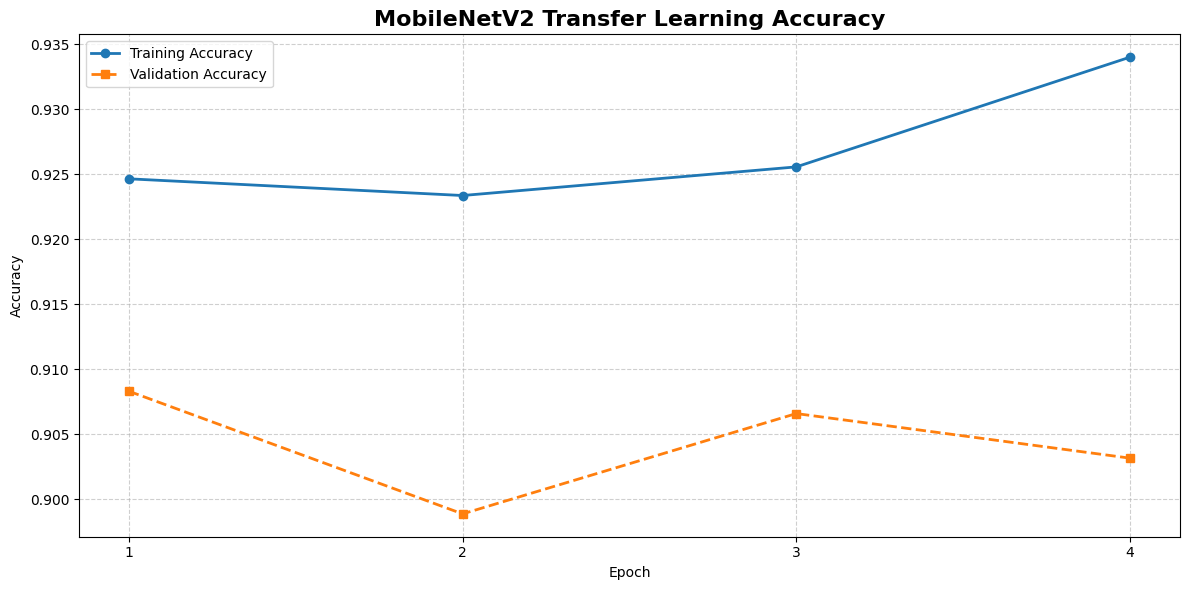

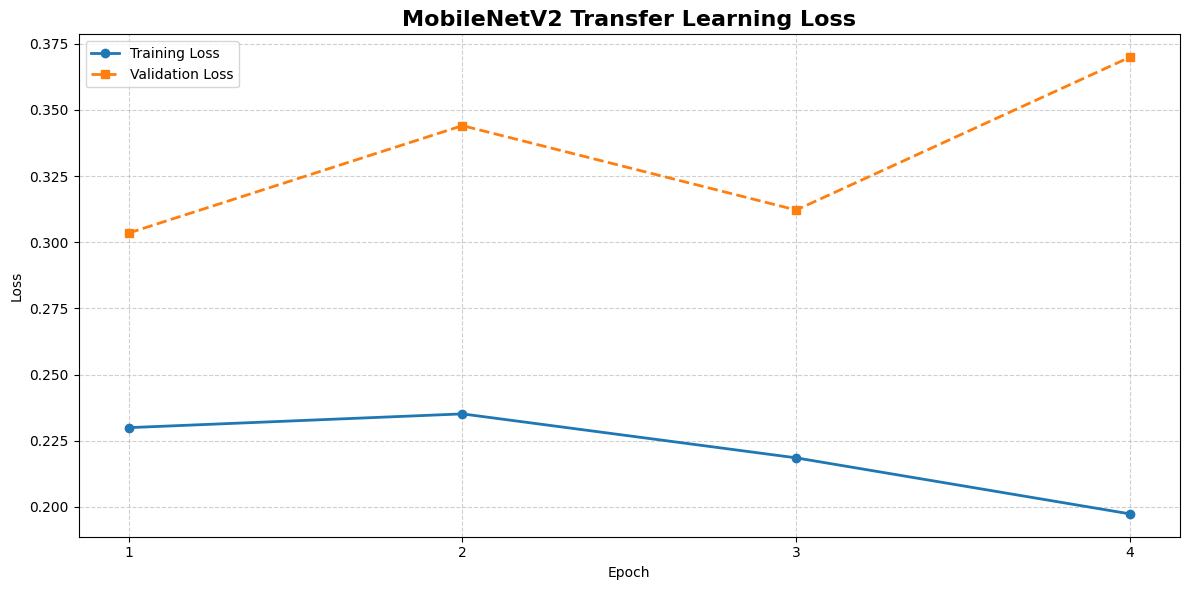

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 39: Plot Accuracy and Loss Curves
# ============================================================

acc = transfer_history.history.get("accuracy", [])
val_acc = transfer_history.history.get("val_accuracy", [])
loss = transfer_history.history.get("loss", [])
val_loss = transfer_history.history.get("val_loss", [])

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, acc, marker="o", linewidth=2, label="Training Accuracy")
plt.plot(epochs_range, val_acc, marker="s", linewidth=2, linestyle="--", label="Validation Accuracy")
plt.title("MobileNetV2 Transfer Learning Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, loss, marker="o", linewidth=2, label="Training Loss")
plt.plot(epochs_range, val_loss, marker="s", linewidth=2, linestyle="--", label="Validation Loss")
plt.title("MobileNetV2 Transfer Learning Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Transfer Learning Model Evaluation

## Evaluation on Test Dataset

The MobileNetV2 transfer learning model is evaluated on the unseen test dataset to measure its classification accuracy, loss, and overall generalization performance.

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 40: Evaluate Transfer Model on Test Data
# ============================================================

print("=" * 70)
print("Evaluating MobileNetV2 Transfer Learning Model on Test Dataset")
print("=" * 70)

transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(
    test_generator,
    verbose=1
)

print("=" * 70)
print("TRANSFER LEARNING TEST PERFORMANCE")
print("=" * 70)
print(f"Model              : MobileNetV2")
print(f"Strategy           : Frozen Base Feature Extraction")
print(f"Test Accuracy      : {transfer_test_accuracy:.4f}")
print(f"Test Loss          : {transfer_test_loss:.4f}")
print(f"Training Time (sec): {transfer_training_time:.2f}")
print(f"Training Time (min): {transfer_training_time / 60:.2f}")
print("=" * 70)

Evaluating MobileNetV2 Transfer Learning Model on Test Dataset
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.9211 - loss: 0.2781
TRANSFER LEARNING TEST PERFORMANCE
Model              : MobileNetV2
Strategy           : Frozen Base Feature Extraction
Test Accuracy      : 0.9211
Test Loss          : 0.2781
Training Time (sec): 312.19
Training Time (min): 5.20


## Classification Report for Transfer Learning Model

A detailed classification report is generated to evaluate the MobileNetV2 transfer learning model using precision, recall, F1-score, and overall accuracy across all sports categories.

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 41: Classification Report
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Reset generator to ensure correct order
test_generator.reset()

# Predictions
transfer_pred_probs = transfer_model.predict(
    test_generator,
    verbose=1
)

transfer_pred_classes = np.argmax(transfer_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Class labels (safe ordering)
class_labels = list(test_generator.class_indices.keys())

# Generate classification report
transfer_report_dict = classification_report(
    y_true,
    transfer_pred_classes,
    target_names=class_labels,
    output_dict=True,
    zero_division=0
)

# Convert to DataFrame
transfer_report_df = pd.DataFrame(transfer_report_dict).transpose()

print("=" * 70)
print("TRANSFER LEARNING CLASSIFICATION REPORT")
print("=" * 70)

# Display clean rounded table
display(transfer_report_df.round(4))

print("=" * 70)

37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step
TRANSFER LEARNING CLASSIFICATION REPORT


,precision,recall,f1-score,support
badminton,0.9015,0.8623,0.8815,138.0000
basketball,0.9286,0.8904,0.9091,73.0000
boxing,0.9810,0.9810,0.9810,105.0000
chess,0.9028,0.9155,0.9091,71.0000
cricket,0.8774,0.9394,0.9073,99.0000
football,0.9187,0.9658,0.9417,117.0000
formula1,0.9490,0.9208,0.9347,101.0000
hockey,0.8765,0.8452,0.8606,84.0000
shooting,0.9494,0.9494,0.9494,79.0000
swimming,0.9266,0.9902,0.9573,102.0000


# Final Model Comparison

## Accuracy Comparison Across All Models

The classification accuracy of all models developed in this project is compared to identify the best-performing architecture and training strategy for sports image classification.

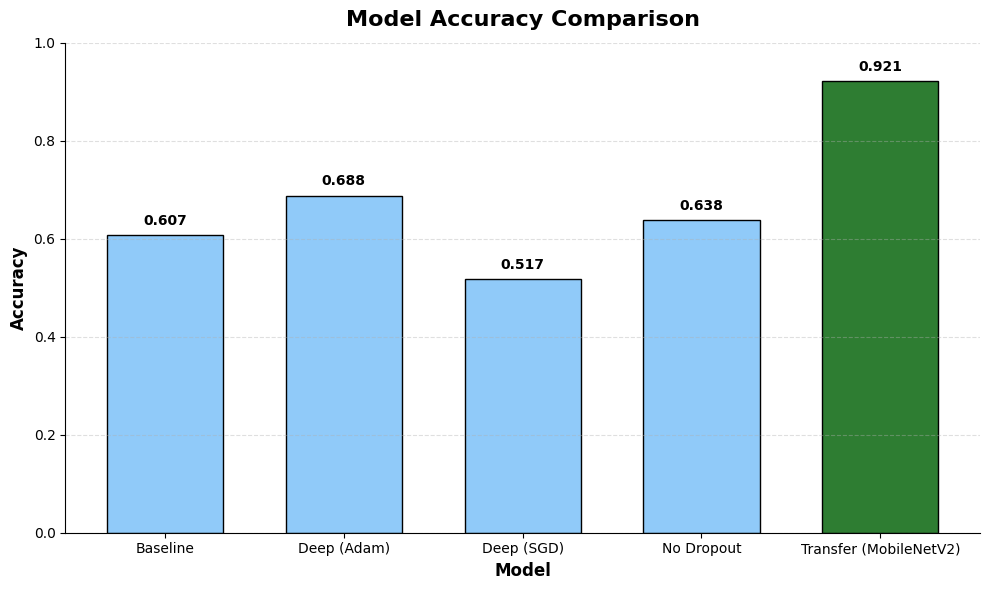

In [ ]:
# ============================================================
# Phase 10: Model Accuracy Comparison Plot 
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

models = [
    "Baseline",
    "Deep (Adam)",
    "Deep (SGD)",
    "No Dropout",
    "Transfer (MobileNetV2)"
]

accuracies = [
    test_accuracy,
    deep_test_accuracy,
    sgd_test_accuracy,
    no_dropout_accuracy,
    transfer_test_accuracy
]

# Colors: highlight best (Transfer) in green, others in blue
colors = ["#90CAF9"] * 4 + ["#2E7D32"]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor="black", width=0.65)

# Titles & labels
plt.title("Model Accuracy Comparison", fontsize=16, fontweight="bold", pad=12)
plt.xlabel("Model", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.ylim(0, 1)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Annotate values
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.015,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Clean spines
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Confusion Matrix for Transfer Learning Model

A normalized confusion matrix is used to visualize the classification performance of the MobileNetV2 transfer learning model and identify class-wise prediction accuracy and misclassification patterns.

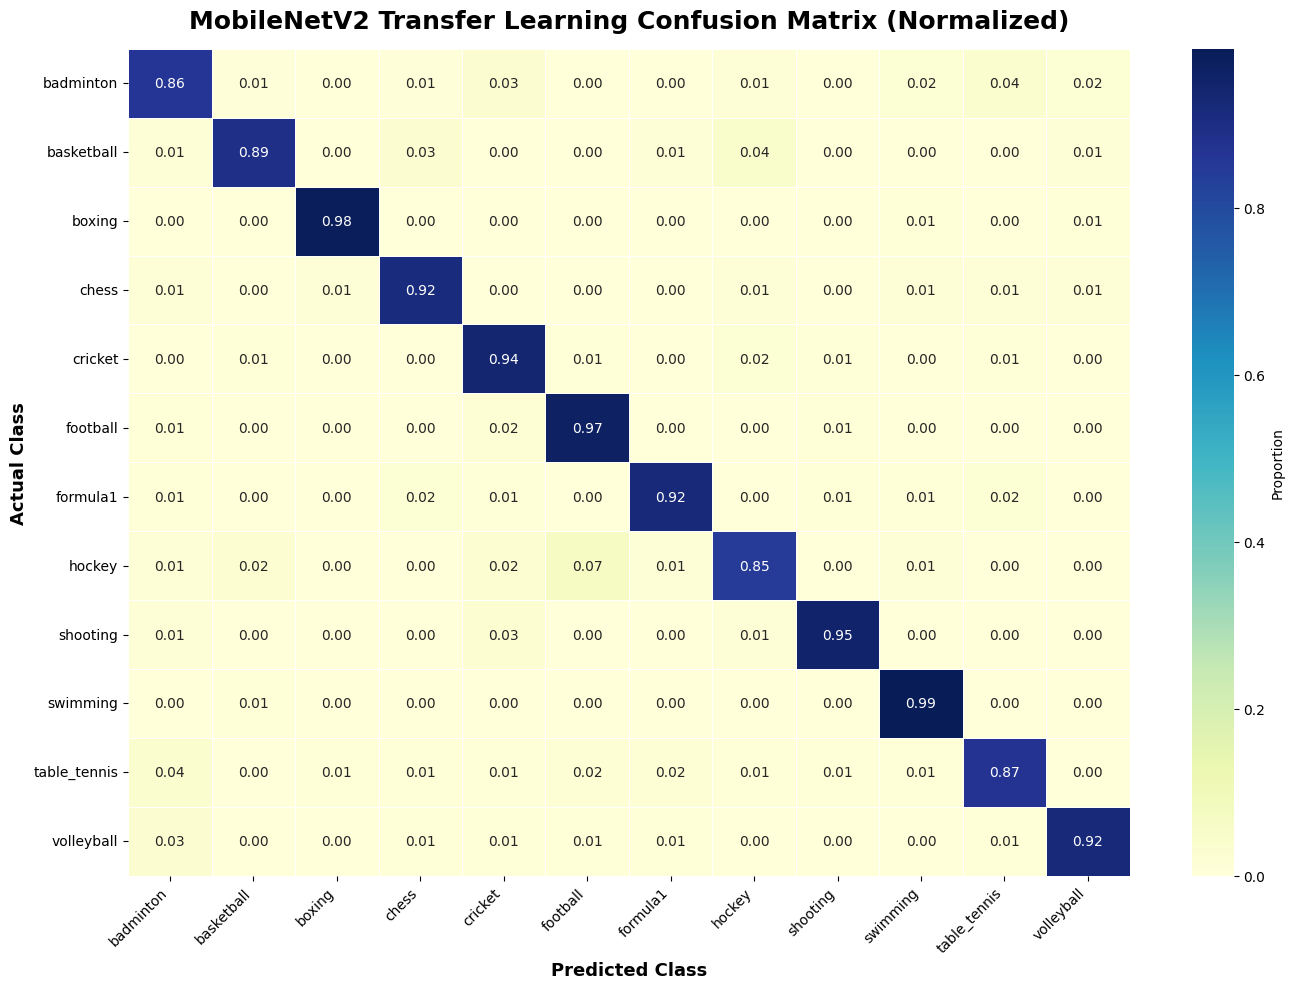

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 42: Confusion Matrix 
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm_transfer = confusion_matrix(y_true, transfer_pred_classes)

# Normalize (avoid division by zero just in case)
cm_normalized = cm_transfer.astype('float') / np.maximum(cm_transfer.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",  
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion"}
)

plt.title("MobileNetV2 Transfer Learning Confusion Matrix (Normalized)",
          fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Class", fontsize=13, fontweight="bold")
plt.ylabel("Actual Class", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

## Overall Performance Metrics Visualization

The overall precision, recall, and F1-score of the MobileNetV2 transfer learning model are visualized to summarize its classification performance on the test dataset.

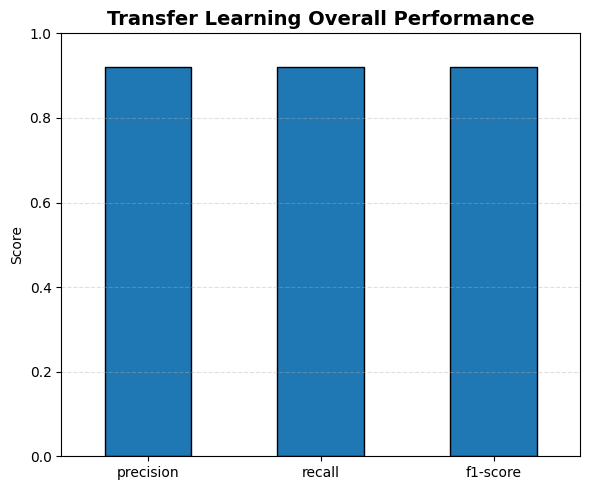

In [ ]:
# ============================================================
# Transfer Learning Metrics Visualization
# ============================================================

import matplotlib.pyplot as plt

metrics = transfer_report_df.loc["weighted avg", ["precision", "recall", "f1-score"]]

metrics.plot(kind="bar", figsize=(6, 5), edgecolor="black")

plt.title("Transfer Learning Overall Performance", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Sample Prediction Visualization for Transfer Learning

Sample predictions from the MobileNetV2 transfer learning model are visualized to compare the actual and predicted sports classes on unseen test images.

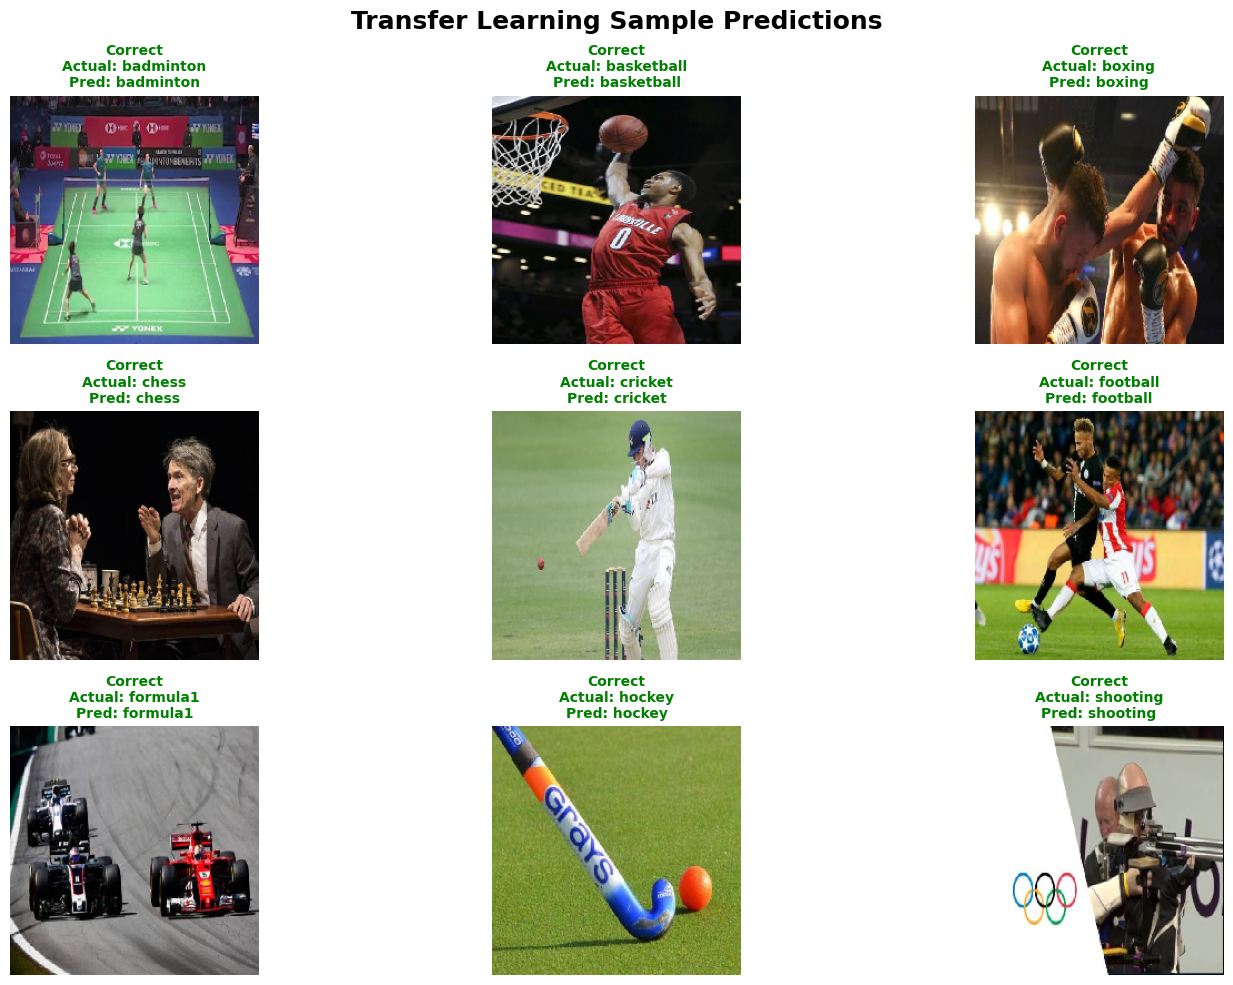

In [ ]:
# ============================================================
# Phase 9: Transfer Learning
# Step 43: Sample Predictions
# ============================================================

test_generator.reset()

sample_images = []
sample_true_labels = []
sample_pred_labels = []

seen_classes = set()

for images, labels in test_generator:
    preds = transfer_model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    for i in range(len(images)):
        true_label = class_labels[true_classes[i]]
        pred_label = class_labels[pred_classes[i]]

        if true_label not in seen_classes:
            sample_images.append(images[i])
            sample_true_labels.append(true_label)
            sample_pred_labels.append(pred_label)
            seen_classes.add(true_label)

        if len(sample_images) >= 9:
            break

    if len(sample_images) >= 9:
        break

plt.figure(figsize=(16, 10))

for i in range(len(sample_images)):
    is_correct = sample_true_labels[i] == sample_pred_labels[i]
    color = "green" if is_correct else "red"
    status = "Correct" if is_correct else "Wrong"

    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i])
    plt.title(
        f"{status}\nActual: {sample_true_labels[i]}\nPred: {sample_pred_labels[i]}",
        color=color,
        fontsize=10,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Transfer Learning Sample Predictions", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

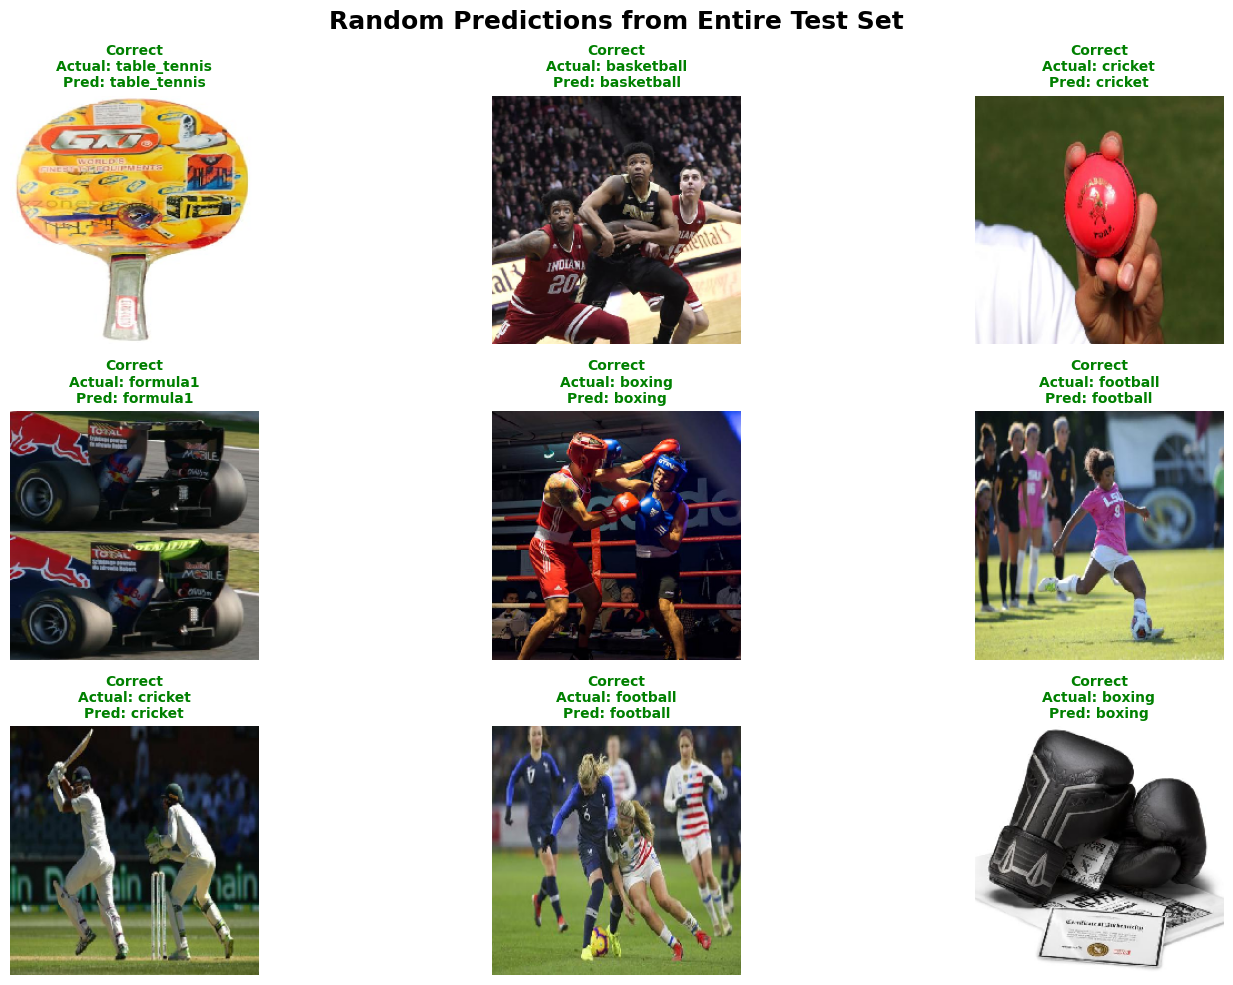

In [ ]:
# ============================================================
# Extra: Truly Random Predictions from Entire Test Set
# ============================================================

import numpy as np
import random

test_generator.reset()

all_images = []
all_true = []
all_pred = []

# Collect from entire test set
for images, labels in test_generator:
    preds = transfer_model.predict(images, verbose=0)

    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    for i in range(len(images)):
        all_images.append(images[i])
        all_true.append(class_labels[true_classes[i]])
        all_pred.append(class_labels[pred_classes[i]])

    if len(all_images) >= test_generator.samples:
        break

# Pick truly random 9 samples from whole dataset
indices = random.sample(range(len(all_images)), 9)

plt.figure(figsize=(16, 10))

for i, idx in enumerate(indices):
    img = all_images[idx]
    true_label = all_true[idx]
    pred_label = all_pred[idx]

    is_correct = true_label == pred_label
    color = "green" if is_correct else "red"
    status = "Correct" if is_correct else "Wrong"

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(
        f"{status}\nActual: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=10,
        fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Random Predictions from Entire Test Set", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

# Final Performance Comparison

## Comparison of All Models

The performance of all models developed in this project is compared using test accuracy, test loss, and training time to identify the most effective image classification approach.

In [ ]:
# ============================================================
# Phase 10: Final Model Comparison Table
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "Deep CNN (Adam)",
        "Deep CNN (SGD)",
        "Deep CNN (No Dropout)",
        "Transfer Learning (MobileNetV2)"
    ],
    "Test Accuracy": [
        test_accuracy,
        deep_test_accuracy,
        sgd_test_accuracy,
        no_dropout_accuracy,
        transfer_test_accuracy
    ],
    "Test Loss": [
        test_loss,
        deep_test_loss,
        sgd_test_loss,
        no_dropout_loss,
        transfer_test_loss
    ],
    "Training Time (sec)": [
        baseline_training_time,
        deep_training_time,
        sgd_training_time,
        no_dropout_time,
        transfer_training_time
    ]
})

# Clean formatting
final_comparison = final_comparison.round({
    "Test Accuracy": 4,
    "Test Loss": 4,
    "Training Time (sec)": 2
})

# Sort by best accuracy
final_comparison = final_comparison.sort_values(
    by="Test Accuracy",
    ascending=False
).reset_index(drop=True)

print("=" * 75)
print("FINAL MODEL PERFORMANCE COMPARISON (ALL MODELS)")
print("=" * 75)

display(final_comparison)

FINAL MODEL PERFORMANCE COMPARISON (ALL MODELS)


,Model,Test Accuracy,Test Loss,Training Time (sec)
0,Transfer Learning (MobileNetV2),0.9211,0.2781,312.19
1,Deep CNN (Adam),0.6876,0.9976,1788.68
2,Deep CNN (No Dropout),0.6375,1.1288,843.83
3,Baseline CNN,0.6070,1.4563,1552.83
4,Deep CNN (SGD),0.5170,1.3943,1720.03


## Final Performance Summary

### Final Model Comparison

| Model | Test Accuracy | Test Loss | Training Time |
|:---|:---|:---|:---|
| **Transfer Learning (MobileNetV2)** | **92.11%** | **0.2781** | **5.20 min** |
| **Deep CNN (Adam)** | **68.76%** | **0.9976** | **29.81 min** |
| **Deep CNN (No Dropout)** | **63.75%** | **1.1288** | **14.06 min** |
| **Baseline CNN** | **60.70%** | **1.4563** | **25.88 min** |
| **Deep CNN (SGD)** | **51.70%** | **1.3943** | **28.67 min** |

### Key Observations

- The MobileNetV2 transfer learning model achieved the highest classification accuracy among all models.
- Transfer learning significantly outperformed all CNN models trained from scratch.
- The pretrained ImageNet features improved feature extraction and generalization performance.
- MobileNetV2 also required the shortest training time despite achieving the best accuracy.
- Deep CNN with Adam was the strongest model among the architectures trained from scratch.

### Final Conclusion

This project demonstrated the effectiveness of Convolutional Neural Networks and transfer learning for multi-class sports image classification. Different CNN architectures, optimizers, and regularization techniques were explored and compared throughout the experiments. Among all models, the MobileNetV2 transfer learning approach achieved the best overall performance with a test accuracy of **92.11%**, showing the advantage of using pretrained deep learning models for image classification tasks. The results also showed that deeper architectures, Batch Normalization, Dropout regularization, and the Adam optimizer improved classification accuracy and model generalization compared to the baseline CNN model.